# Practice Banks
## Redes confiables para credit scoring

Este notebook reorganiza el trabajo final de la practica en una historia clara y defendible. El objetivo es construir, auditar y comparar modelos de credit scoring con:

- benchmarks clasicos;
- red neuronal con capa financiera custom;
- FAIR loss contra dependencia de genero;
- seleccion de lambda con validation y varias semillas;
- AutoML con Keras Tuner;
- calibracion, thresholds por coste y bootstrap;
- MC Dropout para incertidumbre como fiabilidad del modelo;
- tablas y figuras listas para entrega.

La idea central es sencilla: **train entrena, validation decide y test reporta**. Esa regla evita data leakage y separa decisiones metodologicas de evaluacion final.


## 0. Regla metodologica central

Todas las decisiones se fijan con `validation`, no con `test`.

Esto aplica a:

- `lambda_corr` de la FAIR loss;
- thresholds de clasificacion;
- calibracion Platt Scaling;
- umbral de alta incertidumbre;
- seleccion de capa custom original vs adaptativa;
- interpretacion de politicas de revision humana.

El conjunto de `test` se reserva para reportar el comportamiento final una vez tomadas esas decisiones.


## 0.1 Configuracion y reproducibilidad

`FAST_MODE` permite depurar rapido. Para resultados finales debe usarse `FAST_MODE=False`.

Variables clave:

- `SAMPLE_FRAC`: usa todo el dataset o una muestra.
- `N_BOOTSTRAP`: numero de remuestreos para intervalos de confianza.
- `N_MC_SAMPLES`: pasadas de MC Dropout.
- `SEEDS_FAIR_SWEEP`: semillas para reducir dependencia de una unica inicializacion.

Tambien se fija `RANDOM_STATE=42`.


## 0.2 Mapa de requisitos de la practica

| Requisito | Como se aborda en el notebook |
|---|---|
| Dataset Home Credit | Carga de `application_train.csv` |
| Variable objetivo | `TARGET`: 1 indica dificultad de pago |
| Variable sensible | `CODE_GENDER`, codificada como `SENSITIVE_GENDER` y excluida de predictores |
| Preprocesado sin leakage | Imputacion, escalado y one-hot ajustados solo con train |
| Capa custom | Ratios financieros raw con saturacion `tanh` |
| FAIR loss | BCE + penalizacion por correlacion prediccion-genero |
| AutoML | Keras Tuner para arquitectura predictiva y auditoria fairness posterior |
| Incertidumbre | MC Dropout sin BatchNormalization |
| Salida con clase e incertidumbre | `test_predictions_with_uncertainty.csv` |
| Revision humana | Politica selectiva con umbral p90 de validation |
| Evidencia estadistica | Bootstrap final Base vs FAIR |
| Entrega reproducible | Tablas en `tables/`, figuras en `figures/`, README y guion |


In [1]:
import os
import sys
import json
import math
import random
import shutil
import tempfile
import warnings
import subprocess
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from scipy import sparse

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import compute_sample_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

FAST_MODE = False
SAMPLE_FRAC = 0.25 if FAST_MODE else 1.0
N_BOOTSTRAP = 100 if FAST_MODE else 500
N_MC_SAMPLES = 30 if FAST_MODE else 100
SEEDS_FAIR_SWEEP = [42] if FAST_MODE else [42, 123, 2026]

RANDOM_STATE = 42
MAX_EPOCHS = 35 if FAST_MODE else 80
FAIRNESS_EPOCHS = 25 if FAST_MODE else 50
ABLATION_EPOCHS = 25 if FAST_MODE else 50
BATCH_SIZE = 1024
FAIR_BATCH_SIZE = 2048
TUNER_MAX_TRIALS = 5 if FAST_MODE else 15

RUN_KERAS_TUNER = True
INSTALL_KERAS_TUNER_IF_MISSING = True

DATA_PATH = Path("application_train.csv")
TABLE_DIR = Path("tables")
FIGURE_DIR = Path("figures")
MODEL_DIR = Path("models")

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    if directory.exists() and not directory.is_dir():
        raise NotADirectoryError(f"{directory.resolve()} existe pero no es una carpeta.")
    directory.mkdir(parents=True, exist_ok=True)

TUNER_DIR = Path(tempfile.gettempdir()) / "home_credit_aml_keras_tuner_v2_critica"
TUNER_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

reset_seeds(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("FAST_MODE:", FAST_MODE)
print("SAMPLE_FRAC:", SAMPLE_FRAC)
print("N_BOOTSTRAP:", N_BOOTSTRAP)
print("N_MC_SAMPLES:", N_MC_SAMPLES)
print("SEEDS_FAIR_SWEEP:", SEEDS_FAIR_SWEEP)


TensorFlow: 2.21.0
FAST_MODE: False
SAMPLE_FRAC: 1.0
N_BOOTSTRAP: 500
N_MC_SAMPLES: 100
SEEDS_FAIR_SWEEP: [42, 123, 2026]


In [2]:
def ensure_keras_tuner():
    if importlib.util.find_spec("keras_tuner") is None:
        if not INSTALL_KERAS_TUNER_IF_MISSING:
            print("keras-tuner no esta instalado. Se omitira AutoML.")
            return None
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "keras-tuner"])
        except Exception as exc:
            print(f"No se pudo instalar keras-tuner: {exc}. Se omitira AutoML.")
            return None

    try:
        import keras_tuner as kt
        return kt
    except Exception as exc:
        print(f"keras-tuner no pudo importarse: {exc}. Se omitira AutoML.")
        return None


kt = ensure_keras_tuner() if RUN_KERAS_TUNER else None


## 1. Carga y primera auditoria de datos

Se carga `application_train.csv`, se filtra `CODE_GENDER` a `M` y `F`, y se codifica:

- `F = 0`
- `M = 1`

`CODE_GENDER` no entra como predictor. Se usa solo para FAIR loss y auditoria de sesgo.


Shape: (307507, 123)
Tasa global de impago:
0.08072986956394489


,TARGET,proporcion
0,0,0.9193
1,1,0.0807


,CODE_GENDER,n,tasa_impago
0,F,202448,0.0700
1,M,105059,0.1014


,variable,missing_%
0,COMMONAREA_AVG,69.8722
1,COMMONAREA_MEDI,69.8722
2,COMMONAREA_MODE,69.8722
3,NONLIVINGAPARTMENTS_MODE,69.4332
4,NONLIVINGAPARTMENTS_MEDI,69.4332
5,NONLIVINGAPARTMENTS_AVG,69.4332
6,FONDKAPREMONT_MODE,68.3864
7,LIVINGAPARTMENTS_MEDI,68.3552
8,LIVINGAPARTMENTS_MODE,68.3552
9,LIVINGAPARTMENTS_AVG,68.3552


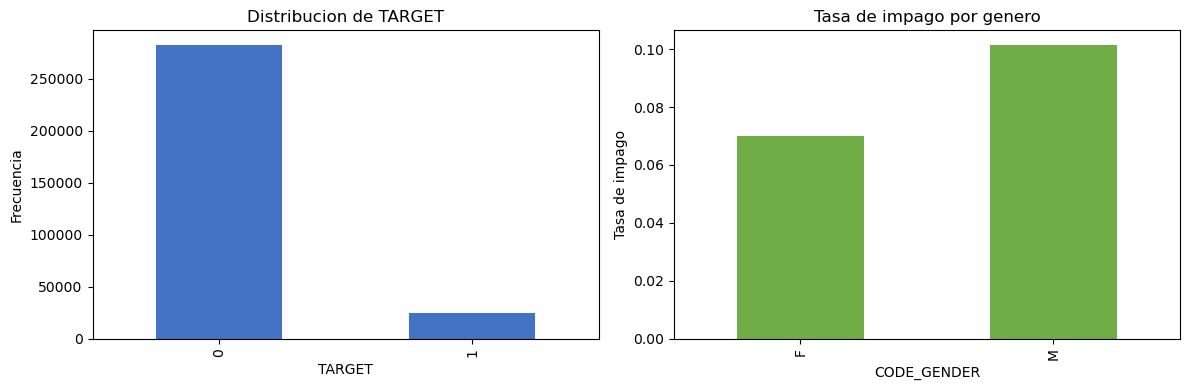

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError("No se encontro application_train.csv en la carpeta del notebook.")

df = pd.read_csv(DATA_PATH)
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).sort_index().reset_index(drop=True)

required_cols = ["TARGET", "CODE_GENDER"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Faltan columnas obligatorias: {missing_required}")

df = df[df["CODE_GENDER"].isin(["M", "F"])].copy()
df["TARGET"] = df["TARGET"].astype("int8")
df["SENSITIVE_GENDER"] = df["CODE_GENDER"].map({"F": 0, "M": 1}).astype("int8")

print("Shape:", df.shape)
print("Tasa global de impago:")
print(df["TARGET"].mean())

display(df["TARGET"].value_counts(normalize=True).rename_axis("TARGET").reset_index(name="proporcion"))
display(df.groupby("CODE_GENDER")["TARGET"].agg(n="count", tasa_impago="mean").reset_index())

missing_pct = df.isna().mean().mul(100).sort_values(ascending=False).rename("missing_%").reset_index()
missing_pct = missing_pct.rename(columns={"index": "variable"})
display(missing_pct.head(25))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["TARGET"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4472C4")
axes[0].set_title("Distribucion de TARGET")
axes[0].set_xlabel("TARGET")
axes[0].set_ylabel("Frecuencia")
df.groupby("CODE_GENDER")["TARGET"].mean().plot(kind="bar", ax=axes[1], color="#70AD47")
axes[1].set_title("Tasa de impago por genero")
axes[1].set_xlabel("CODE_GENDER")
axes[1].set_ylabel("Tasa de impago")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "exploracion_target_genero.png", dpi=140, bbox_inches="tight")
plt.show()


## 2. Feature engineering financiero

Los ratios financieros se calculan antes del escalado porque tienen interpretacion economica en unidades originales:

- cuota anual / ingresos;
- credito / ingresos;
- cuota anual / credito;
- precio del bien / credito;
- fuentes externas disponibles o ausentes.

Tambien se crean agregados de `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3`, porque la practica pide reflexionar sobre calidad de informacion e incertidumbre.


In [4]:
epsilon = 1e-6

def safe_divide(numerator, denominator, eps=epsilon):
    return numerator / (denominator.replace(0, np.nan) + eps)


if "DAYS_EMPLOYED" in df.columns:
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df["ANNUITY_INCOME_RATIO"] = safe_divide(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
df["CREDIT_INCOME_RATIO"] = safe_divide(df["AMT_CREDIT"], df["AMT_INCOME_TOTAL"])
df["ANNUITY_CREDIT_RATIO"] = safe_divide(df["AMT_ANNUITY"], df["AMT_CREDIT"])
df["GOODS_CREDIT_RATIO"] = safe_divide(df["AMT_GOODS_PRICE"], df["AMT_CREDIT"])
df["EMPLOYED_AGE_RATIO"] = safe_divide(df["DAYS_EMPLOYED"], df["DAYS_BIRTH"])

EXT_SOURCE_COLS = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["EXT_SOURCE_MEAN"] = df[EXT_SOURCE_COLS].mean(axis=1)
df["EXT_SOURCE_STD"] = df[EXT_SOURCE_COLS].std(axis=1)
df["EXT_SOURCE_MIN"] = df[EXT_SOURCE_COLS].min(axis=1)
df["EXT_SOURCE_MAX"] = df[EXT_SOURCE_COLS].max(axis=1)
df["EXT_SOURCE_MISSING_COUNT"] = df[EXT_SOURCE_COLS].isna().sum(axis=1)
df["EXT_SOURCE_AVAILABLE_COUNT"] = 3 - df["EXT_SOURCE_MISSING_COUNT"]
df.replace([np.inf, -np.inf], np.nan, inplace=True)

ENGINEERED_FINANCIAL_RATIOS = [
    "ANNUITY_INCOME_RATIO",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_CREDIT_RATIO",
    "GOODS_CREDIT_RATIO",
    "EMPLOYED_AGE_RATIO",
]

NUMERIC_FEATURES = [
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "REGION_RATING_CLIENT",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_CREDIT_RATIO",
    "GOODS_CREDIT_RATIO",
    "EMPLOYED_AGE_RATIO",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_STD",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX",
    "EXT_SOURCE_MISSING_COUNT",
]

CATEGORICAL_FEATURES = [
    "NAME_CONTRACT_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

financial_raw_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
NUMERIC_FEATURES_NO_RATIOS = [c for c in NUMERIC_FEATURES if c not in ENGINEERED_FINANCIAL_RATIOS]
FEATURES_NO_RATIOS = NUMERIC_FEATURES_NO_RATIOS + CATEGORICAL_FEATURES

missing_predictors = [c for c in FEATURES + financial_raw_cols if c not in df.columns]
if missing_predictors:
    raise ValueError(f"Faltan variables predictoras esperadas: {missing_predictors}")

assert "CODE_GENDER" not in FEATURES
assert "SENSITIVE_GENDER" not in FEATURES

display(pd.DataFrame({"numeric_features": NUMERIC_FEATURES}))
display(pd.DataFrame({"categorical_features": CATEGORICAL_FEATURES}))


,numeric_features
0,AMT_INCOME_TOTAL
1,AMT_ANNUITY
2,AMT_CREDIT
3,AMT_GOODS_PRICE
4,DAYS_BIRTH
5,DAYS_EMPLOYED
6,CNT_CHILDREN
7,CNT_FAM_MEMBERS
8,REGION_RATING_CLIENT
9,EXT_SOURCE_1


,categorical_features
0,NAME_CONTRACT_TYPE
1,FLAG_OWN_CAR
2,FLAG_OWN_REALTY
3,NAME_INCOME_TYPE
4,NAME_EDUCATION_TYPE
5,NAME_FAMILY_STATUS
6,NAME_HOUSING_TYPE
7,OCCUPATION_TYPE
8,ORGANIZATION_TYPE


## 3. Split train / validation / test y preprocesado sin leakage

El split es estratificado para mantener la tasa de default en train, validation y test.

El preprocesado sigue esta regla:

- train ajusta imputadores, escaladores y one-hot;
- validation elige lambdas, thresholds y calibradores;
- test se transforma con objetos ya ajustados y se usa para reporte.

Ademas se separan las variables financieras raw que necesita la capa custom.


In [5]:
X = df[FEATURES].copy()
X_no_ratios = df[FEATURES_NO_RATIOS].copy()
y = df["TARGET"].copy()
s = df["SENSITIVE_GENDER"].copy()
ids = df["SK_ID_CURR"].copy() if "SK_ID_CURR" in df.columns else pd.Series(df.index, name="SK_ID_CURR")

X_train_raw, X_temp_raw, X_train_no_ratios_raw, X_temp_no_ratios_raw, y_train, y_temp, s_train, s_temp, ids_train, ids_temp = train_test_split(
    X,
    X_no_ratios,
    y,
    s,
    ids,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val_raw, X_test_raw, X_val_no_ratios_raw, X_test_no_ratios_raw, y_val, y_test, s_val, s_test, ids_val, ids_test = train_test_split(
    X_temp_raw,
    X_temp_no_ratios_raw,
    y_temp,
    s_temp,
    ids_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

def make_preprocessor(numeric_features, categorical_features):
    try:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse=True)
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", one_hot)]), categorical_features),
        ],
        remainder="drop",
    )

def to_dense_float32(matrix):
    if sparse.issparse(matrix):
        return matrix.toarray().astype(np.float32)
    return np.asarray(matrix, dtype=np.float32)

preprocessor = make_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
X_train_keras = to_dense_float32(preprocessor.fit_transform(X_train_raw))
X_val_keras = to_dense_float32(preprocessor.transform(X_val_raw))
X_test_keras = to_dense_float32(preprocessor.transform(X_test_raw))

preprocessor_no_ratios = make_preprocessor(NUMERIC_FEATURES_NO_RATIOS, CATEGORICAL_FEATURES)
X_train_no_ratios_keras = to_dense_float32(preprocessor_no_ratios.fit_transform(X_train_no_ratios_raw))
X_val_no_ratios_keras = to_dense_float32(preprocessor_no_ratios.transform(X_val_no_ratios_raw))
X_test_no_ratios_keras = to_dense_float32(preprocessor_no_ratios.transform(X_test_no_ratios_raw))

financial_imputer = SimpleImputer(strategy="median")
X_train_fin_raw = financial_imputer.fit_transform(X_train_raw[financial_raw_cols]).astype(np.float32)
X_val_fin_raw = financial_imputer.transform(X_val_raw[financial_raw_cols]).astype(np.float32)
X_test_fin_raw = financial_imputer.transform(X_test_raw[financial_raw_cols]).astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.float32)
y_val_np = y_val.to_numpy().astype(np.float32)
y_test_np = y_test.to_numpy().astype(np.float32)
s_train_np = s_train.to_numpy().astype(np.float32)
s_val_np = s_val.to_numpy().astype(np.float32)
s_test_np = s_test.to_numpy().astype(np.float32)

input_dim = X_train_keras.shape[1]
input_dim_no_ratios = X_train_no_ratios_keras.shape[1]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "default_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "male_rate": [s_train.mean(), s_val.mean(), s_test.mean()],
})
display(split_summary)
print("Processed input:", X_train_keras.shape, X_val_keras.shape, X_test_keras.shape)
print("Processed input sin ratios:", X_train_no_ratios_keras.shape, X_val_no_ratios_keras.shape, X_test_no_ratios_keras.shape)
print("Raw financial input:", X_train_fin_raw.shape, X_val_fin_raw.shape, X_test_fin_raw.shape)


,split,rows,default_rate,male_rate
0,train,215254,0.0807,0.3417
1,validation,46126,0.0807,0.3430
2,test,46127,0.0807,0.3402


Processed input: (215254, 129) (46126, 129) (46127, 129)
Processed input sin ratios: (215254, 124) (46126, 124) (46127, 124)
Raw financial input: (215254, 4) (46126, 4) (46127, 4)


## 4. Metricas, thresholds, costes y bootstrap

Se definen metricas predictivas y de fairness.

Predictivas:

- ROC-AUC;
- PR-AUC;
- accuracy y balanced accuracy;
- precision, recall y F1;
- Brier Score.

Fairness:

- correlacion entre score y genero;
- demographic parity gap;
- equal opportunity gap;
- FPR gap.

La accuracy no basta porque la tasa de default ronda el 8%, asi que el dataset esta muy desbalanceado.


In [6]:
def _safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_score = np.asarray(y_score).astype(float).ravel()
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

def _safe_pr_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_score = np.asarray(y_score).astype(float).ravel()
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return average_precision_score(y_true, y_score)
    except Exception:
        return np.nan

def _safe_corr(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    if len(a) < 2 or np.nanstd(a) < 1e-12 or np.nanstd(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def _group_rate(values, mask):
    values = np.asarray(values)
    mask = np.asarray(mask).astype(bool)
    return float(values[mask].mean()) if mask.sum() > 0 else np.nan

def _tpr_fpr_by_group(y_true, y_pred, sensitive, group_value):
    mask = np.asarray(sensitive).astype(int) == group_value
    if mask.sum() == 0:
        return np.nan, np.nan
    yt = np.asarray(y_true).astype(int)[mask]
    yp = np.asarray(y_pred).astype(int)[mask]
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return tpr, fpr

def evaluate_model(name, y_true, y_proba, sensitive, threshold=0.5, threshold_strategy="fixed_0.5"):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_proba = np.asarray(y_proba).astype(float).ravel()
    sensitive = np.asarray(sensitive).astype(int).ravel()
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    male_mask = sensitive == 1
    female_mask = sensitive == 0
    mean_pred_male = _group_rate(y_proba, male_mask)
    mean_pred_female = _group_rate(y_proba, female_mask)
    label_rate_male = _group_rate(y_pred, male_mask)
    label_rate_female = _group_rate(y_pred, female_mask)
    tpr_male, fpr_male = _tpr_fpr_by_group(y_true, y_pred, sensitive, 1)
    tpr_female, fpr_female = _tpr_fpr_by_group(y_true, y_pred, sensitive, 0)

    return {
        "model": name,
        "threshold_strategy": threshold_strategy,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": _safe_roc_auc(y_true, y_proba),
        "pr_auc": _safe_pr_auc(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "mean_prediction": float(np.mean(y_proba)),
        "default_rate_real": float(np.mean(y_true)),
        "corr_pred_gender": _safe_corr(y_proba, sensitive),
        "demographic_parity_gap_score": abs(mean_pred_male - mean_pred_female)
            if not (np.isnan(mean_pred_male) or np.isnan(mean_pred_female)) else np.nan,
        "demographic_parity_gap_label": abs(label_rate_male - label_rate_female)
            if not (np.isnan(label_rate_male) or np.isnan(label_rate_female)) else np.nan,
        "equal_opportunity_gap": abs(tpr_male - tpr_female)
            if not (np.isnan(tpr_male) or np.isnan(tpr_female)) else np.nan,
        "fpr_gap": abs(fpr_male - fpr_female)
            if not (np.isnan(fpr_male) or np.isnan(fpr_female)) else np.nan,
    }

def find_best_threshold(y_true, y_proba, metric="f1"):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_threshold = 0.5
    best_score = -np.inf
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, y_pred)
        else:
            raise ValueError("metric debe ser 'f1' o 'balanced_accuracy'")
        if score > best_score:
            best_score = score
            best_threshold = threshold
    return float(best_threshold), float(best_score)

def cost_at_threshold(y_true, y_proba, threshold, cost_fp=1.0, cost_fn=5.0):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return float(cost_fp * fp + cost_fn * fn)

def find_best_threshold_by_cost(y_true, y_proba, cost_fp=1.0, cost_fn=5.0):
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = [cost_at_threshold(y_true, y_proba, t, cost_fp, cost_fn) for t in thresholds]
    idx = int(np.argmin(costs))
    return float(thresholds[idx]), float(costs[idx])

def make_callbacks(monitor="val_auc", mode="max", patience=8):
    return [
        keras.callbacks.EarlyStopping(monitor=monitor, mode=mode, patience=patience, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor=monitor, mode=mode, patience=max(2, patience // 2), factor=0.5, min_lr=1e-6, verbose=1),
    ]

def plot_training_history(history, model_name, filename):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(hist.index + 1, hist["loss"], label="loss")
    if "val_loss" in hist:
        axes[0].plot(hist.index + 1, hist["val_loss"], label="val_loss")
    axes[0].set_title(f"{model_name}: loss")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    if "auc" in hist:
        axes[1].plot(hist.index + 1, hist["auc"], label="auc")
    if "val_auc" in hist:
        axes[1].plot(hist.index + 1, hist["val_auc"], label="val_auc")
    axes[1].set_title(f"{model_name}: AUC")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    if "pr_auc" in hist:
        axes[2].plot(hist.index + 1, hist["pr_auc"], label="pr_auc")
    if "val_pr_auc" in hist:
        axes[2].plot(hist.index + 1, hist["val_pr_auc"], label="val_pr_auc")
    axes[2].set_title(f"{model_name}: PR-AUC")
    axes[2].legend()
    axes[2].grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()

def bootstrap_metric_ci(y_true, y_pred_a, y_pred_b=None, sensitive=None, metric_func=None, n_boot=500, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_a)
    y_pred_b = None if y_pred_b is None else np.asarray(y_pred_b)
    sensitive = None if sensitive is None else np.asarray(sensitive)
    values = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            if y_pred_b is None:
                val = metric_func(y_true[idx], y_pred_a[idx], None if sensitive is None else sensitive[idx])
            else:
                val = metric_func(y_true[idx], y_pred_a[idx], y_pred_b[idx], None if sensitive is None else sensitive[idx])
        except Exception:
            continue
        if pd.notna(val):
            values.append(float(val))
    if not values:
        return np.nan, np.nan, np.nan, 0
    arr = np.asarray(values)
    return float(np.mean(arr)), float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5)), int(len(arr))

def ci_text(row):
    return f"[{row['ci_95_low']:.4f}, {row['ci_95_high']:.4f}]"


## 5. Benchmarks clasicos

Antes de defender la red neuronal, se comparan modelos clasicos:

- DummyClassifier;
- Logistic Regression;
- HistGradientBoosting.

Estos modelos sirven como referencia predictiva. El objetivo de la practica no es solo ganar AUC, sino integrar capa custom, fairness e incertidumbre.


In [7]:
results_full_test = []

classic_models = {
    "Dummy prior": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05, l2_regularization=0.01, random_state=RANDOM_STATE),
}

for model_name, model in classic_models.items():
    print(f"Entrenando {model_name}...")
    model.fit(X_train_keras, y_train_np)
    val_proba = model.predict_proba(X_val_keras)[:, 1]
    test_proba = model.predict_proba(X_test_keras)[:, 1]
    threshold, val_f1 = find_best_threshold(y_val_np, val_proba, metric="f1")
    metrics = evaluate_model(model_name, y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
    metrics["evaluation_scope"] = "full_test"
    metrics["validation_best_f1"] = val_f1
    results_full_test.append(metrics)

display(pd.DataFrame(results_full_test))


Entrenando Dummy prior...
Entrenando Logistic Regression...
Entrenando HistGradientBoosting...


  File "c:\Users\david\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\david\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\david\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\david\anaconda3\Lib\subprocess.

,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,evaluation_scope,validation_best_f1
0,Dummy prior,best_f1_validation,0.0100,0.0807,0.5000,0.5000,0.0807,0.0742,0.0807,1.0000,0.1494,0,42403,0,3724,0.0807,0.0807,NaN,0.0000,0.0000,0.0000,0.0000,full_test,0.1494
1,Logistic Regression,best_f1_validation,0.6600,0.8396,0.6494,0.7470,0.2346,0.2051,0.2306,0.4227,0.2984,37152,5251,2150,1574,0.4249,0.0807,0.1338,0.0563,0.0751,0.0904,0.0641,full_test,0.2919
2,HistGradientBoosting,best_f1_validation,0.1600,0.8588,0.6513,0.7605,0.2552,0.0674,0.2594,0.4039,0.3159,38110,4293,2220,1504,0.0809,0.0807,0.1172,0.0194,0.0645,0.1009,0.0514,full_test,0.3083


## 6. Arquitectura neuronal, capa custom y FAIR loss

La red usa dos entradas:

- features preprocesadas;
- variables financieras raw.

La capa `DebtRatioSaturationLayer` calcula ratios internos y aplica `tanh` para limitar outliers. Se usa `LayerNormalization` y no `BatchNormalization`, porque MC Dropout requiere inferencia con `training=True` y BatchNorm contaminaria la varianza.


In [8]:
classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np.astype(int))
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(classes, class_weights)}
sample_weight_train = compute_sample_weight("balanced", y_train_np.astype(int)).astype(np.float32)
sample_weight_val = compute_sample_weight("balanced", y_val_np.astype(int)).astype(np.float32)
print("class_weight:", class_weight_dict)

class DebtRatioSaturationLayer(keras.layers.Layer):
    def __init__(self, units=8, alpha=1.0, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.alpha = alpha
        self.epsilon = epsilon
        self.projection = layers.Dense(units, activation="relu")

    def call(self, inputs):
        income = inputs[:, 0:1]
        annuity = inputs[:, 1:2]
        credit = inputs[:, 2:3]
        goods = inputs[:, 3:4]
        ratios = tf.concat(
            [
                annuity / (income + self.epsilon),
                credit / (income + self.epsilon),
                annuity / (credit + self.epsilon),
                goods / (credit + self.epsilon),
            ],
            axis=-1,
        )
        saturated = tf.math.tanh(self.alpha * ratios)
        return self.projection(saturated)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units, "alpha": self.alpha, "epsilon": self.epsilon})
        return cfg

def correlation_penalty(y_pred, sensitive, eps=1e-7):
    y_pred = tf.reshape(tf.cast(y_pred, tf.float32), (-1, 1))
    sensitive = tf.reshape(tf.cast(sensitive, tf.float32), (-1, 1))
    pred_centered = y_pred - tf.reduce_mean(y_pred)
    sens_centered = sensitive - tf.reduce_mean(sensitive)
    numerator = tf.reduce_mean(pred_centered * sens_centered)
    denominator = tf.sqrt(tf.reduce_mean(tf.square(pred_centered)) * tf.reduce_mean(tf.square(sens_centered)) + eps)
    return tf.square(numerator / denominator)

class FairCorrelationLoss(keras.losses.Loss):
    def __init__(self, lambda_corr=0.3, eps=1e-7, name="fair_correlation_loss"):
        super().__init__(name=name)
        self.lambda_corr = lambda_corr
        self.eps = eps

    def call(self, y_true_ext, y_pred):
        y_true = tf.reshape(tf.cast(y_true_ext[:, 0], tf.float32), (-1, 1))
        sensitive = tf.reshape(tf.cast(y_true_ext[:, 1], tf.float32), (-1, 1))
        y_pred = tf.reshape(tf.cast(y_pred, tf.float32), (-1, 1))
        bce = keras.losses.binary_crossentropy(y_true, y_pred)
        return bce + self.lambda_corr * correlation_penalty(y_pred, sensitive, self.eps)

    def get_config(self):
        return {"lambda_corr": self.lambda_corr, "eps": self.eps, "name": self.name}

def make_fair_y(y_values, sensitive_values):
    return np.column_stack([
        np.asarray(y_values).astype(np.float32).ravel(),
        np.asarray(sensitive_values).astype(np.float32).ravel(),
    ]).astype(np.float32)

y_train_ext = make_fair_y(y_train_np, s_train_np)
y_val_ext = make_fair_y(y_val_np, s_val_np)

def add_norm_layer(x, use_batch_norm=False, use_layer_norm=True, name=None):
    if use_batch_norm:
        return layers.BatchNormalization(name=None if name is None else f"{name}_batchnorm")(x)
    if use_layer_norm:
        return layers.LayerNormalization(name=None if name is None else f"{name}_layernorm")(x)
    return x

def build_dense_model(processed_dim, dense_units=(64, 32), dropout_rates=(0.25, 0.20), learning_rate=1e-3,
                      use_batch_norm=False, use_layer_norm=True, fair_lambda=None, model_name="dense_model"):
    processed_input = keras.Input(shape=(processed_dim,), name="processed_input")
    x = processed_input
    for i, units in enumerate(dense_units):
        x = layers.Dense(units, activation="relu", name=f"dense_{i+1}")(x)
        x = add_norm_layer(x, use_batch_norm, use_layer_norm, name=f"norm_{i+1}")
        dropout = dropout_rates[i] if i < len(dropout_rates) else dropout_rates[-1]
        x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)
    model = keras.Model(processed_input, output, name=model_name)
    compile_model(model, fair_lambda=fair_lambda, learning_rate=learning_rate)
    return model

def build_custom_layer_model(processed_dim, dense_units=(64, 32), dropout_rates=(0.25, 0.20), learning_rate=1e-3,
                             use_batch_norm=False, use_layer_norm=True, fair_lambda=None, model_name="custom_model"):
    processed_input = keras.Input(shape=(processed_dim,), name="processed_input")
    raw_financial_input = keras.Input(shape=(4,), name="raw_financial_input")
    financial_features = DebtRatioSaturationLayer(units=8, alpha=1.0, name="debt_ratio_saturation")(raw_financial_input)
    x = layers.Concatenate(name="concat_processed_financial")([processed_input, financial_features])
    for i, units in enumerate(dense_units):
        x = layers.Dense(units, activation="relu", name=f"dense_{i+1}")(x)
        x = add_norm_layer(x, use_batch_norm, use_layer_norm, name=f"norm_{i+1}")
        dropout = dropout_rates[i] if i < len(dropout_rates) else dropout_rates[-1]
        x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)
    model = keras.Model([processed_input, raw_financial_input], output, name=model_name)
    compile_model(model, fair_lambda=fair_lambda, learning_rate=learning_rate)
    return model

def compile_model(model, fair_lambda=None, learning_rate=1e-3):
    if fair_lambda is None:
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss=keras.losses.BinaryCrossentropy(),
            metrics=[keras.metrics.AUC(name="auc"), keras.metrics.AUC(curve="PR", name="pr_auc")],
        )
    else:
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss=FairCorrelationLoss(lambda_corr=fair_lambda),
            metrics=[],
        )

def assert_no_batchnorm(model):
    batchnorm_layers = [
        layer.name for layer in model.layers
        if isinstance(layer, tf.keras.layers.BatchNormalization)
    ]
    if batchnorm_layers:
        raise ValueError(
            f"El modelo usado para MC Dropout contiene BatchNormalization: {batchnorm_layers}. "
            "Usa LayerNormalization o elimina BatchNorm."
        )


class_weight: {0: 0.5439085896794473, 1: 6.193646774472003}


### 6.1 Limitacion de la FAIR loss

La FAIR loss penaliza la correlacion entre prediccion y genero dentro de cada batch:

`BCE + lambda_corr * corr(prediccion, genero)^2`

Es una aproximacion estocastica, no una garantia absoluta de no discriminacion. Por eso el notebook audita fairness globalmente en validation y test.


## 7. Candidato base con capa original

Primero se entrena una red con la capa financiera original y sin FAIR loss. Esta fase sirve para verificar que la arquitectura funciona y para obtener una referencia neuronal inicial. La decision final se toma mas adelante.



Epoch 1/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.6948 - loss: 0.6495 - pr_auc: 0.1580 - val_auc: 0.7397 - val_loss: 0.5858 - val_pr_auc: 0.2123 - learning_rate: 0.0010
Epoch 2/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7275 - loss: 0.6121 - pr_auc: 0.1908 - val_auc: 0.7442 - val_loss: 0.5873 - val_pr_auc: 0.2204 - learning_rate: 0.0010
Epoch 3/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7344 - loss: 0.6055 - pr_auc: 0.2026 - val_auc: 0.7460 - val_loss: 0.5810 - val_pr_auc: 0.2249 - learning_rate: 0.0010
Epoch 4/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7385 - loss: 0.6022 - pr_auc: 0.2073 - val_auc: 0.7472 - val_loss: 0.5769 - val_pr_auc: 0.2266 - learning_rate: 0.0010
Epoch 5/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7414 - loss: 0.5996 - pr_auc: 0.2100 - val_auc: 0.7483 - val_loss: 0.5744 - val_pr_auc: 0.2296 - learning_rate: 0.0010
Epoch 6/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7431 - loss: 0.5983 - pr_auc: 0.2127 -

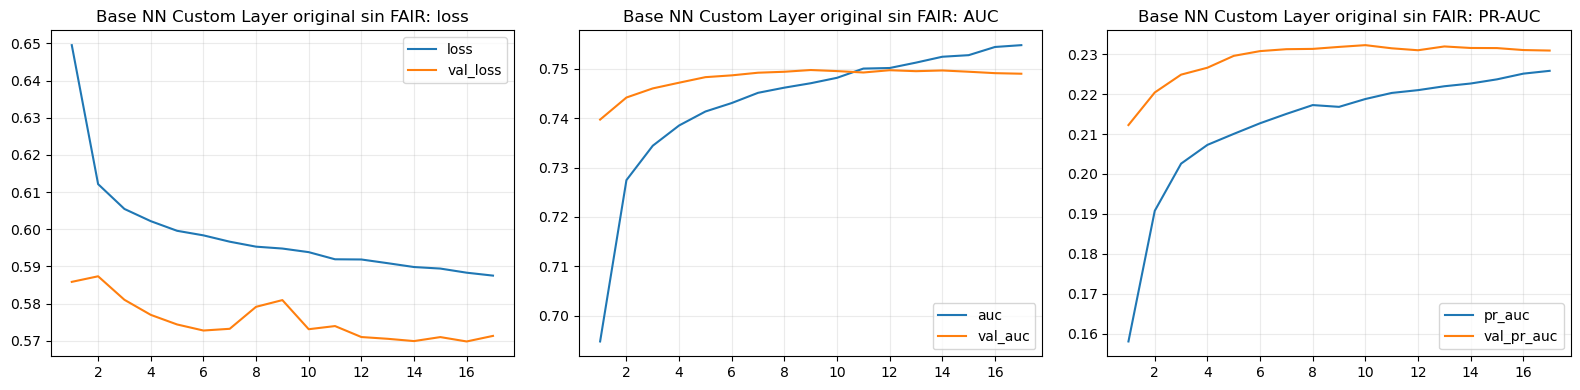

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap
0,Base NN Custom Layer original sin FAIR,best_f1_validation,0.6500,0.8410,0.6474,0.7497,0.2319,0.1982,0.2311,0.4165,0.2973,37243,5159,2173,1551,0.4192,0.0807,0.1430,0.0567,0.0798,0.1074,0.0669


In [9]:
reset_seeds(42)
base_custom_model = build_custom_layer_model(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    use_batch_norm=False,
    use_layer_norm=True,
    fair_lambda=None,
    model_name="Base_NN_CustomLayer_NoFair_Original",
)
assert_no_batchnorm(base_custom_model)

history_base_custom = base_custom_model.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_np,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_np),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(monitor="val_auc", mode="max", patience=8),
    verbose=1,
)
plot_training_history(history_base_custom, "Base NN Custom Layer original sin FAIR", "loss_curve_base_custom_no_fair.png")

y_val_proba_base_original = base_custom_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
best_threshold_base_original, best_val_f1_base_original = find_best_threshold(
    y_val_np,
    y_val_proba_base_original,
    metric="f1",
)
base_validation_metrics_original = evaluate_model(
    "Base NN Custom Layer original sin FAIR",
    y_val_np,
    y_val_proba_base_original,
    s_val_np,
    threshold=best_threshold_base_original,
    threshold_strategy="best_f1_validation",
)
display(pd.DataFrame([base_validation_metrics_original]))


## 8. Sweep FAIR multi-seed con capa original

Se prueban varios valores de `lambda_corr` y varias semillas. La seleccion de lambda se basa en medias de validation, buscando reducir dependencia con genero sin perder demasiado AUC.


In [10]:
lambdas = [0.0, 0.05, 0.1, 0.3, 0.5, 0.8, 1.0]
lambda_seed_val_rows = []
lambda_seed_test_rows = []

for seed in SEEDS_FAIR_SWEEP:
    for lambda_corr in lambdas:
        print(f"Entrenando FAIR seed={seed}, lambda={lambda_corr}...")
        reset_seeds(seed)
        tf.keras.backend.clear_session()
        model = build_custom_layer_model(
            processed_dim=input_dim,
            dense_units=(64, 32),
            dropout_rates=(0.25, 0.20),
            learning_rate=1e-3,
            use_batch_norm=False,
            use_layer_norm=True,
            fair_lambda=lambda_corr,
            model_name=f"Fair_seed_{seed}_lambda_{lambda_corr}",
        )
        assert_no_batchnorm(model)
        model.fit(
            [X_train_keras, X_train_fin_raw],
            y_train_ext,
            validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
            sample_weight=sample_weight_train,
            epochs=FAIRNESS_EPOCHS,
            batch_size=FAIR_BATCH_SIZE,
            callbacks=make_callbacks(monitor="val_loss", mode="min", patience=5),
            verbose=0,
        )
        val_proba = model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        test_proba = model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        val_metrics = evaluate_model("fair_seed_validation", y_val_np, val_proba, s_val_np, threshold, "best_f1_validation")
        test_metrics = evaluate_model("fair_seed_test", y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
        lambda_seed_val_rows.append({
            "seed": seed,
            "lambda_corr": lambda_corr,
            "split": "validation",
            "threshold": threshold,
            "roc_auc": val_metrics["roc_auc"],
            "pr_auc": val_metrics["pr_auc"],
            "corr_pred_gender": val_metrics["corr_pred_gender"],
            "abs_corr_pred_gender": abs(val_metrics["corr_pred_gender"]),
            "demographic_parity_gap_score": val_metrics["demographic_parity_gap_score"],
            "equal_opportunity_gap": val_metrics["equal_opportunity_gap"],
            "fpr_gap": val_metrics["fpr_gap"],
            "precision": val_metrics["precision"],
            "recall": val_metrics["recall"],
            "f1": val_metrics["f1"],
        })
        lambda_seed_test_rows.append({
            "seed": seed,
            "lambda_corr": lambda_corr,
            "split": "test",
            "threshold": threshold,
            "roc_auc": test_metrics["roc_auc"],
            "pr_auc": test_metrics["pr_auc"],
            "corr_pred_gender": test_metrics["corr_pred_gender"],
            "abs_corr_pred_gender": abs(test_metrics["corr_pred_gender"]),
            "demographic_parity_gap_score": test_metrics["demographic_parity_gap_score"],
            "equal_opportunity_gap": test_metrics["equal_opportunity_gap"],
            "fpr_gap": test_metrics["fpr_gap"],
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
        })

lambda_seed_results_validation = pd.DataFrame(lambda_seed_val_rows)
lambda_seed_results_test = pd.DataFrame(lambda_seed_test_rows)
lambda_seed_results_validation.to_csv(TABLE_DIR / "lambda_seed_results_validation.csv", index=False)
lambda_seed_results_test.to_csv(TABLE_DIR / "lambda_seed_results_test.csv", index=False)

val_summary = lambda_seed_results_validation.groupby("lambda_corr").agg(
    val_roc_auc_mean=("roc_auc", "mean"),
    val_roc_auc_std=("roc_auc", "std"),
    val_abs_corr_mean=("abs_corr_pred_gender", "mean"),
    val_abs_corr_std=("abs_corr_pred_gender", "std"),
    val_pr_auc_mean=("pr_auc", "mean"),
    val_demographic_parity_gap_mean=("demographic_parity_gap_score", "mean"),
).reset_index()

test_summary = lambda_seed_results_test.groupby("lambda_corr").agg(
    test_roc_auc_mean=("roc_auc", "mean"),
    test_roc_auc_std=("roc_auc", "std"),
    test_abs_corr_mean=("abs_corr_pred_gender", "mean"),
    test_abs_corr_std=("abs_corr_pred_gender", "std"),
    test_pr_auc_mean=("pr_auc", "mean"),
).reset_index()

lambda_sweep_summary_by_seed = val_summary.merge(test_summary, on="lambda_corr", how="left")
lambda_sweep_summary_by_seed["n_runs"] = len(SEEDS_FAIR_SWEEP)
lambda_sweep_summary_by_seed.to_csv(TABLE_DIR / "lambda_sweep_summary_by_seed.csv", index=False)
lambda_seed_results_validation.rename(columns={
    "roc_auc": "val_roc_auc",
    "pr_auc": "val_pr_auc",
    "corr_pred_gender": "val_corr_pred_gender",
    "abs_corr_pred_gender": "val_abs_corr_pred_gender",
    "demographic_parity_gap_score": "val_demographic_parity_gap_score",
}).to_csv(TABLE_DIR / "lambda_val_results.csv", index=False)
lambda_seed_results_test.rename(columns={
    "roc_auc": "test_roc_auc",
    "pr_auc": "test_pr_auc",
    "corr_pred_gender": "test_corr_pred_gender",
    "abs_corr_pred_gender": "test_abs_corr_pred_gender",
    "demographic_parity_gap_score": "test_demographic_parity_gap_score",
}).to_csv(TABLE_DIR / "lambda_test_results.csv", index=False)

candidate_lambdas = lambda_sweep_summary_by_seed[lambda_sweep_summary_by_seed["val_abs_corr_mean"] < 0.05].copy()
if not candidate_lambdas.empty:
    selected = candidate_lambdas.sort_values("val_roc_auc_mean", ascending=False).iloc[0]
    lambda_selection_rule = "Mayor val_roc_auc_mean con val_abs_corr_mean < 0.05"
else:
    lambda_sweep_summary_by_seed["selection_score"] = (
        lambda_sweep_summary_by_seed["val_roc_auc_mean"] - 0.05 * lambda_sweep_summary_by_seed["val_abs_corr_mean"]
    )
    selected = lambda_sweep_summary_by_seed.sort_values("selection_score", ascending=False).iloc[0]
    lambda_selection_rule = "Mayor val_roc_auc_mean - 0.05 * val_abs_corr_mean"

best_lambda_fair = float(selected["lambda_corr"])
print("best_lambda_fair:", best_lambda_fair)
print("Regla:", lambda_selection_rule)
display(lambda_sweep_summary_by_seed)


Entrenando FAIR seed=42, lambda=0.0...

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 21: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.
Entrenando FAIR seed=42, lambda=0.05...

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 22: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 17.
Entrenando FAIR seed=42, lambda=0.1...

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 18: R

,lambda_corr,val_roc_auc_mean,val_roc_auc_std,val_abs_corr_mean,val_abs_corr_std,val_pr_auc_mean,val_demographic_parity_gap_mean,test_roc_auc_mean,test_roc_auc_std,test_abs_corr_mean,test_abs_corr_std,test_pr_auc_mean,n_runs
0,0.0000,0.7491,0.0007,0.1391,0.0019,0.2296,0.0597,0.7525,0.0006,0.1367,0.0019,0.2395,3
1,0.0500,0.7493,0.0008,0.1182,0.0012,0.2299,0.0508,0.7528,0.0008,0.1159,0.0011,0.2398,3
2,0.1000,0.7490,0.0007,0.1031,0.0007,0.2296,0.0442,0.7526,0.0007,0.1009,0.0007,0.2395,3
3,0.3000,0.7479,0.0008,0.0688,0.0019,0.2289,0.0295,0.7518,0.0006,0.0669,0.0019,0.2389,3
4,0.5000,0.7471,0.0004,0.0513,0.0018,0.2290,0.0218,0.7512,0.0005,0.0498,0.0018,0.2386,3
5,0.8000,0.7465,0.0006,0.0396,0.0036,0.2285,0.0167,0.7509,0.0005,0.0386,0.0037,0.2380,3
6,1.0000,0.7466,0.0007,0.0363,0.0040,0.2284,0.0153,0.7506,0.0006,0.0350,0.0040,0.2382,3


## 9. Candidato FAIR con capa original

Con la mejor lambda del sweep original se entrena un candidato FAIR. Esta no es todavia la decision final: despues se audita la saturacion de `tanh` y se compara contra una capa adaptativa.


Epoch 1/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6700 - val_loss: 0.6083 - learning_rate: 0.0010
Epoch 2/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6241 - val_loss: 0.6040 - learning_rate: 0.0010
Epoch 3/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6142 - val_loss: 0.6022 - learning_rate: 0.0010
Epoch 4/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6101 - val_loss: 0.6010 - learning_rate: 0.0010
Epoch 5/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6075 - val_loss: 0.5999 - learning_rate: 0.0010
Epoch 6/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6048 - val_loss: 0.5995 - learning_rate: 0.0010
Epoch 7/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6041 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 8/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6023 - val_loss: 0.5986 - learning_rate: 0.0010
Epoch 9/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6019 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 10/8

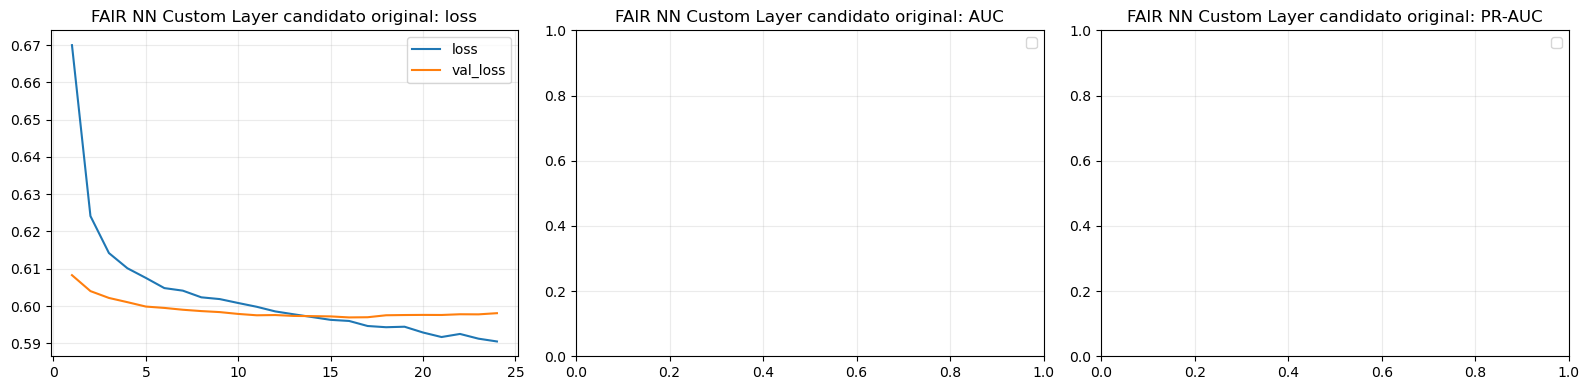

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,lambda_corr
0,FAIR NN Custom Layer candidato original,best_f1_validation,0.6600,0.8465,0.6440,0.7470,0.2301,0.1987,0.2359,0.4025,0.2975,37546,4856,2225,1499,0.4173,0.0807,0.0381,0.0156,0.0449,0.0653,0.0328,1.0000


In [11]:
reset_seeds(42)
tf.keras.backend.clear_session()
best_fair_model = build_custom_layer_model(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    use_batch_norm=False,
    use_layer_norm=True,
    fair_lambda=best_lambda_fair,
    model_name="Fair_NN_CustomLayer_Original_Candidate",
)
assert_no_batchnorm(best_fair_model)

history_best_fair = best_fair_model.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_ext,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
    sample_weight=sample_weight_train,
    epochs=MAX_EPOCHS,
    batch_size=FAIR_BATCH_SIZE,
    callbacks=make_callbacks(monitor="val_loss", mode="min", patience=8),
    verbose=1,
)
plot_training_history(history_best_fair, "FAIR NN Custom Layer candidato original", "loss_curve_best_fair.png")

y_val_proba_fair = best_fair_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
best_threshold_fair, best_val_f1_fair = find_best_threshold(y_val_np, y_val_proba_fair, metric="f1")

best_fair_validation_metrics = evaluate_model(
    "FAIR NN Custom Layer candidato original",
    y_val_np,
    y_val_proba_fair,
    s_val_np,
    best_threshold_fair,
    "best_f1_validation",
)
best_fair_validation_metrics["lambda_corr"] = best_lambda_fair
display(pd.DataFrame([best_fair_validation_metrics]))


## 10. Pareto fairness-performance

La curva Pareto muestra el intercambio entre rendimiento predictivo y dependencia con genero. La decision se apoya en validation; test se conserva como reporte posterior.


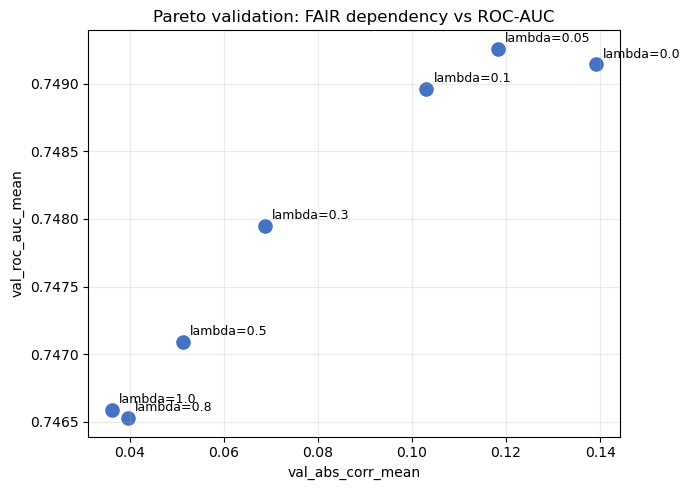

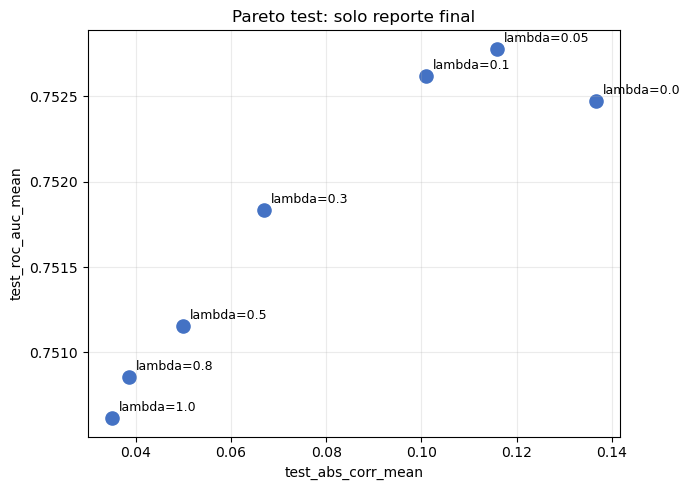

In [12]:
def plot_pareto(df_plot, x_col, y_col, label_col, title, filename):
    plt.figure(figsize=(7, 5))
    plt.scatter(df_plot[x_col], df_plot[y_col], s=90, color="#4472C4")
    for _, row in df_plot.iterrows():
        plt.annotate(f"lambda={row[label_col]}", (row[x_col], row[y_col]), textcoords="offset points", xytext=(5, 5), fontsize=9)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()

plot_pareto(
    lambda_sweep_summary_by_seed,
    "val_abs_corr_mean",
    "val_roc_auc_mean",
    "lambda_corr",
    "Pareto validation: FAIR dependency vs ROC-AUC",
    "pareto_fairness_performance_validation.png",
)
plot_pareto(
    lambda_sweep_summary_by_seed,
    "test_abs_corr_mean",
    "test_roc_auc_mean",
    "lambda_corr",
    "Pareto test: solo reporte final",
    "pareto_fairness_performance_test.png",
)


## 11. Ablation study de la capa custom

Se comparan tres variantes:

- red sin ratios engineered ni capa custom;
- red con ratios engineered como features;
- red con capa financiera custom.

Esto separa aportacion predictiva, interpretabilidad y restriccion financiera.



Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 20: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 15.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.


,model,uses_engineered_ratios,uses_raw_custom_layer,roc_auc_test,pr_auc_test,brier_score_test,precision_test,recall_test,f1_test,corr_pred_gender_test
0,A: NN sin ratios engineered ni capa custom,False,False,0.7487,0.2337,0.1998,0.2338,0.4251,0.3016,0.1477
1,B: NN con ratios engineered sin capa custom,True,False,0.7516,0.2376,0.2000,0.2289,0.4433,0.3019,0.1371
2,C: NN con DebtRatioSaturationLayer,True,True,0.7529,0.2402,0.1995,0.2334,0.4275,0.3019,0.1408


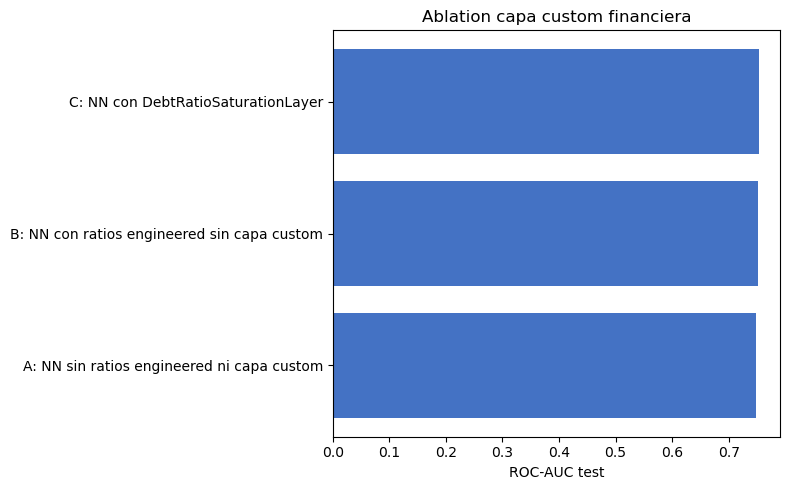

In [13]:
ablation_rows = []

def train_eval_ablation(model_name, model, train_inputs, val_inputs, test_inputs, uses_engineered_ratios, uses_raw_custom_layer):
    history = model.fit(
        train_inputs,
        y_train_np,
        validation_data=(val_inputs, y_val_np),
        epochs=ABLATION_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=make_callbacks(monitor="val_auc", mode="max", patience=5),
        verbose=0,
    )
    val_proba = model.predict(val_inputs, batch_size=BATCH_SIZE, verbose=0).ravel()
    test_proba = model.predict(test_inputs, batch_size=BATCH_SIZE, verbose=0).ravel()
    threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
    metrics = evaluate_model(model_name, y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
    return {
        "model": model_name,
        "uses_engineered_ratios": uses_engineered_ratios,
        "uses_raw_custom_layer": uses_raw_custom_layer,
        "roc_auc_test": metrics["roc_auc"],
        "pr_auc_test": metrics["pr_auc"],
        "brier_score_test": metrics["brier_score"],
        "precision_test": metrics["precision"],
        "recall_test": metrics["recall"],
        "f1_test": metrics["f1"],
        "corr_pred_gender_test": metrics["corr_pred_gender"],
    }


reset_seeds(42)
model_a = build_dense_model(input_dim_no_ratios, use_batch_norm=False, use_layer_norm=True, model_name="A_no_ratios_no_custom")
ablation_rows.append(train_eval_ablation(
    "A: NN sin ratios engineered ni capa custom",
    model_a,
    X_train_no_ratios_keras,
    X_val_no_ratios_keras,
    X_test_no_ratios_keras,
    False,
    False,
))

reset_seeds(42)
model_b = build_dense_model(input_dim, use_batch_norm=False, use_layer_norm=True, model_name="B_ratios_no_custom")
ablation_rows.append(train_eval_ablation(
    "B: NN con ratios engineered sin capa custom",
    model_b,
    X_train_keras,
    X_val_keras,
    X_test_keras,
    True,
    False,
))

reset_seeds(42)
model_c = build_custom_layer_model(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    use_batch_norm=False,
    use_layer_norm=True,
    fair_lambda=None,
    model_name="C_custom_layer_ablation",
)
ablation_rows.append(train_eval_ablation(
    "C: NN con DebtRatioSaturationLayer",
    model_c,
    [X_train_keras, X_train_fin_raw],
    [X_val_keras, X_val_fin_raw],
    [X_test_keras, X_test_fin_raw],
    True,
    True,
))

custom_layer_ablation_results = pd.DataFrame(ablation_rows)
custom_layer_ablation_results.to_csv(TABLE_DIR / "custom_layer_ablation_results.csv", index=False)
display(custom_layer_ablation_results)

plt.figure(figsize=(8, 5))
plt.barh(custom_layer_ablation_results["model"], custom_layer_ablation_results["roc_auc_test"], color="#4472C4")
plt.xlabel("ROC-AUC test")
plt.title("Ablation capa custom financiera")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "custom_layer_ablation_roc_auc.png", dpi=140, bbox_inches="tight")
plt.show()


## 12. Auditoria de saturacion `tanh`

La funcion `tanh` protege frente a outliers, pero si demasiados casos quedan cerca de 1 puede aplastar informacion. Esta auditoria detecta si algun ratio queda excesivamente saturado.


,ratio_name,raw_mean,raw_median,raw_p95,raw_p99,raw_max,saturated_mean,saturated_median,saturated_p95,saturated_p99,saturated_max,pct_saturated_above_0_95,pct_saturated_above_0_99
0,ANNUITY_INCOME_RAW,0.1808,0.1626,0.3549,0.4845,1.5706,0.1770,0.1612,0.3407,0.4498,0.9171,0.0000,0.0000
1,CREDIT_INCOME_RAW,3.9520,3.2531,9.1229,13.0136,49.2272,0.9582,0.9970,1.0000,1.0000,1.0000,0.7976,0.6230
2,ANNUITY_CREDIT_RAW,0.0537,0.0500,0.1050,0.1143,0.1581,0.0536,0.0500,0.1046,0.1138,0.1568,0.0000,0.0000
3,GOODS_CREDIT_RAW,0.9018,0.8938,1.0000,1.0000,6.6667,0.7138,0.7133,0.7616,0.7616,1.0000,0.0008,0.0002


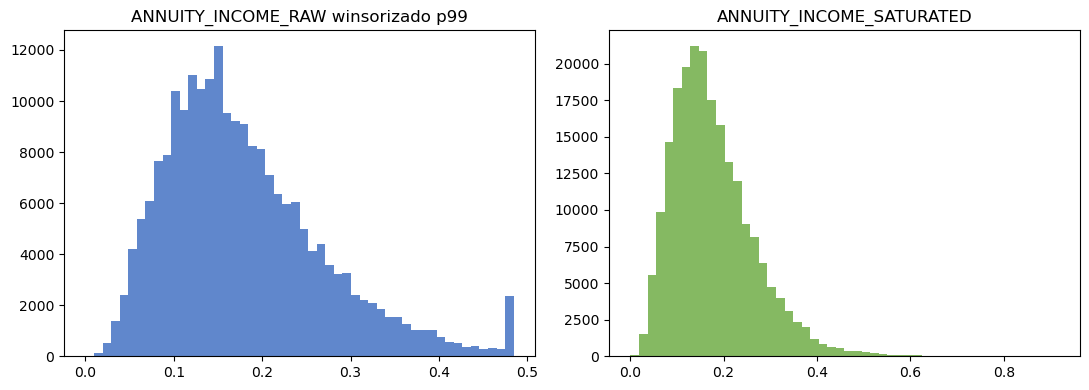

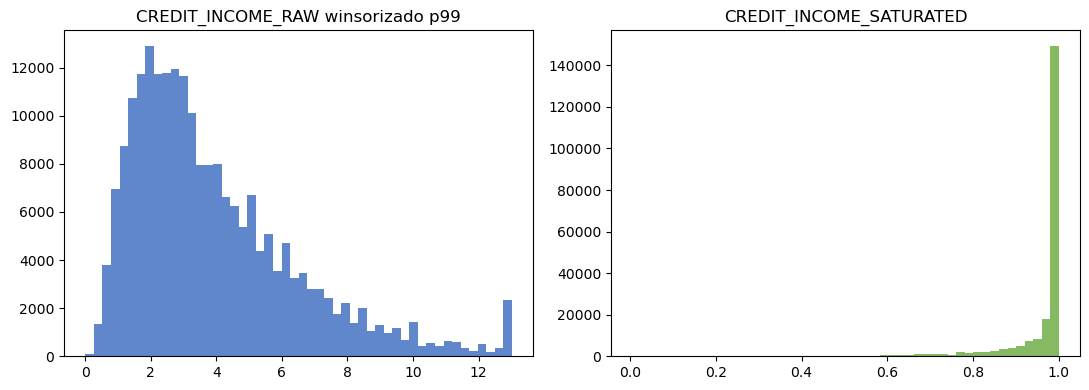

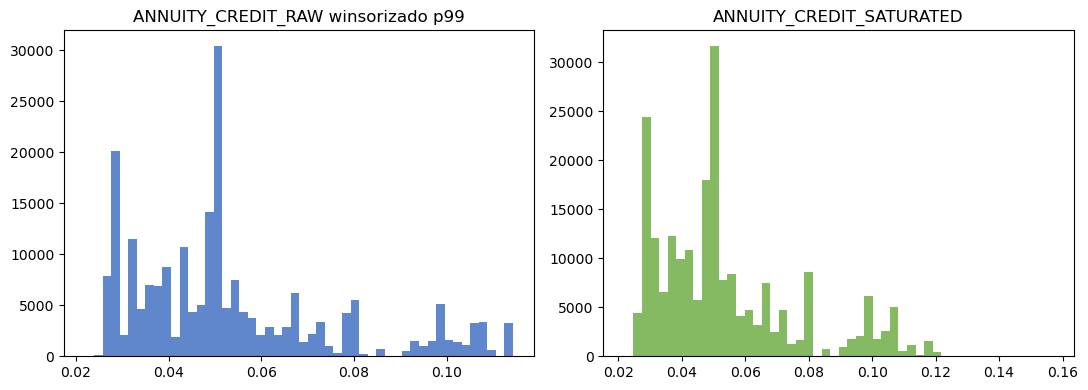

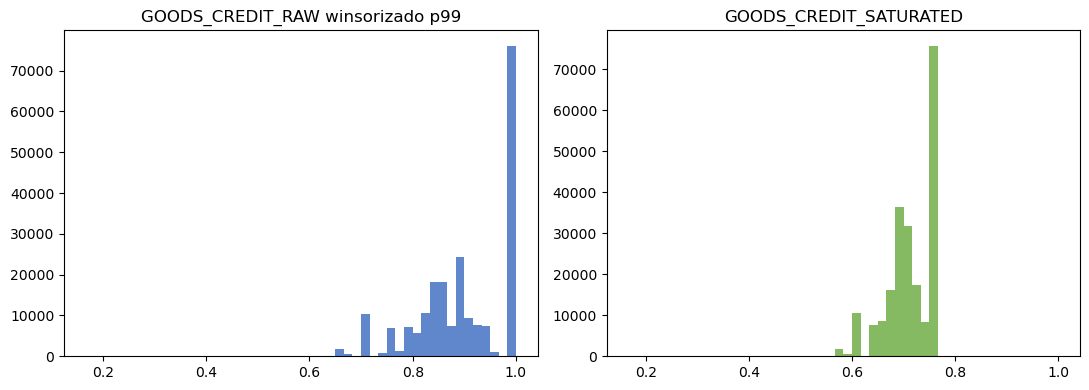

In [14]:
def compute_raw_ratios(raw_matrix, alpha=1.0, eps=1e-6):
    income = raw_matrix[:, 0]
    annuity = raw_matrix[:, 1]
    credit = raw_matrix[:, 2]
    goods = raw_matrix[:, 3]
    ratios = pd.DataFrame({
        "ANNUITY_INCOME_RAW": annuity / (income + eps),
        "CREDIT_INCOME_RAW": credit / (income + eps),
        "ANNUITY_CREDIT_RAW": annuity / (credit + eps),
        "GOODS_CREDIT_RAW": goods / (credit + eps),
    })
    saturated = np.tanh(alpha * ratios)
    saturated.columns = [c.replace("_RAW", "_SATURATED") for c in ratios.columns]
    return ratios, saturated

raw_ratios_train, saturated_ratios_train = compute_raw_ratios(X_train_fin_raw, alpha=1.0)

ratio_rows = []
for raw_col, sat_col in zip(raw_ratios_train.columns, saturated_ratios_train.columns):
    raw = raw_ratios_train[raw_col].replace([np.inf, -np.inf], np.nan).dropna()
    sat = saturated_ratios_train[sat_col].replace([np.inf, -np.inf], np.nan).dropna()
    ratio_rows.append({
        "ratio_name": raw_col,
        "raw_mean": raw.mean(),
        "raw_median": raw.median(),
        "raw_p95": raw.quantile(0.95),
        "raw_p99": raw.quantile(0.99),
        "raw_max": raw.max(),
        "saturated_mean": sat.mean(),
        "saturated_median": sat.median(),
        "saturated_p95": sat.quantile(0.95),
        "saturated_p99": sat.quantile(0.99),
        "saturated_max": sat.max(),
        "pct_saturated_above_0_95": float((sat > 0.95).mean()),
        "pct_saturated_above_0_99": float((sat > 0.99).mean()),
    })

ratio_saturation_summary = pd.DataFrame(ratio_rows)
ratio_saturation_summary.to_csv(TABLE_DIR / "ratio_saturation_summary.csv", index=False)
display(ratio_saturation_summary)

plot_names = {
    "ANNUITY_INCOME_RAW": "ratio_saturation_annuity_income.png",
    "CREDIT_INCOME_RAW": "ratio_saturation_credit_income.png",
    "ANNUITY_CREDIT_RAW": "ratio_saturation_annuity_credit.png",
    "GOODS_CREDIT_RAW": "ratio_saturation_goods_credit.png",
}
for raw_col, filename in plot_names.items():
    sat_col = raw_col.replace("_RAW", "_SATURATED")
    raw = raw_ratios_train[raw_col].replace([np.inf, -np.inf], np.nan).dropna()
    sat = saturated_ratios_train[sat_col].replace([np.inf, -np.inf], np.nan).dropna()
    raw_wins = raw.clip(upper=raw.quantile(0.99))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(raw_wins, bins=50, color="#4472C4", alpha=0.85)
    axes[0].set_title(f"{raw_col} winsorizado p99")
    axes[1].hist(sat, bins=50, color="#70AD47", alpha=0.85)
    axes[1].set_title(f"{sat_col}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()


## 13. AutoML con Keras Tuner

Keras Tuner busca una arquitectura predictiva competitiva usando `val_auc`.

Limitacion importante: este AutoML no es un optimizador Pareto multiobjetivo puro. No optimiza simultaneamente AUC, fairness, calibracion e incertidumbre. Por eso se audita fairness despues y se compara con el sweep de lambdas.


Trial 15 Complete [00h 00m 20s]
val_auc: 0.7463281750679016

Best val_auc So Far: 0.7494707107543945
Total elapsed time: 00h 05m 25s


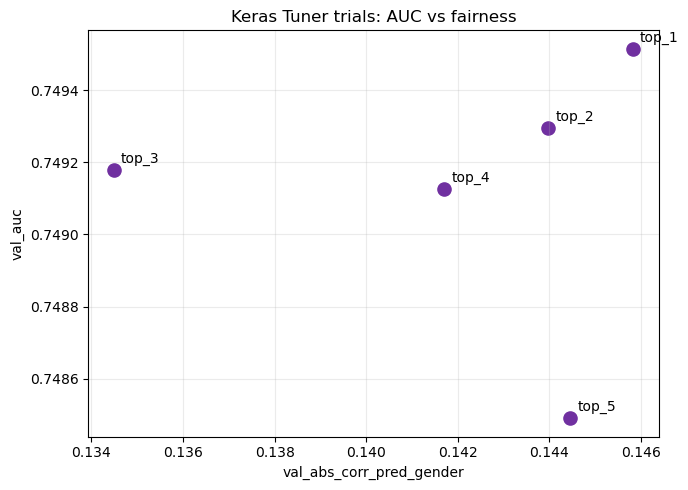

Epoch 1/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.6719 - loss: 0.6663 - pr_auc: 0.1406 - val_auc: 0.7356 - val_loss: 0.5942 - val_pr_auc: 0.1952 - learning_rate: 0.0010
Epoch 2/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7183 - loss: 0.6192 - pr_auc: 0.1796 - val_auc: 0.7412 - val_loss: 0.5924 - val_pr_auc: 0.2088 - learning_rate: 0.0010
Epoch 3/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7266 - loss: 0.6125 - pr_auc: 0.1893 - val_auc: 0.7432 - val_loss: 0.5858 - val_pr_auc: 0.2148 - learning_rate: 0.0010
Epoch 4/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7339 - loss: 0.6066 - pr_auc: 0.1976 - val_auc: 0.7451 - val_loss: 0.5904 - val_pr_auc: 0.2197 - learning_rate: 0.0010
Epoch 5/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7361 - loss: 0.6047 - pr_auc: 0.2008 - val_auc: 0.7457 - val_loss: 0.5934 - val_pr_auc: 0.2213 - learning_rate: 0.0010
Epoch 6/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7389 - loss: 0.6022 - pr_auc: 0.2049 - 

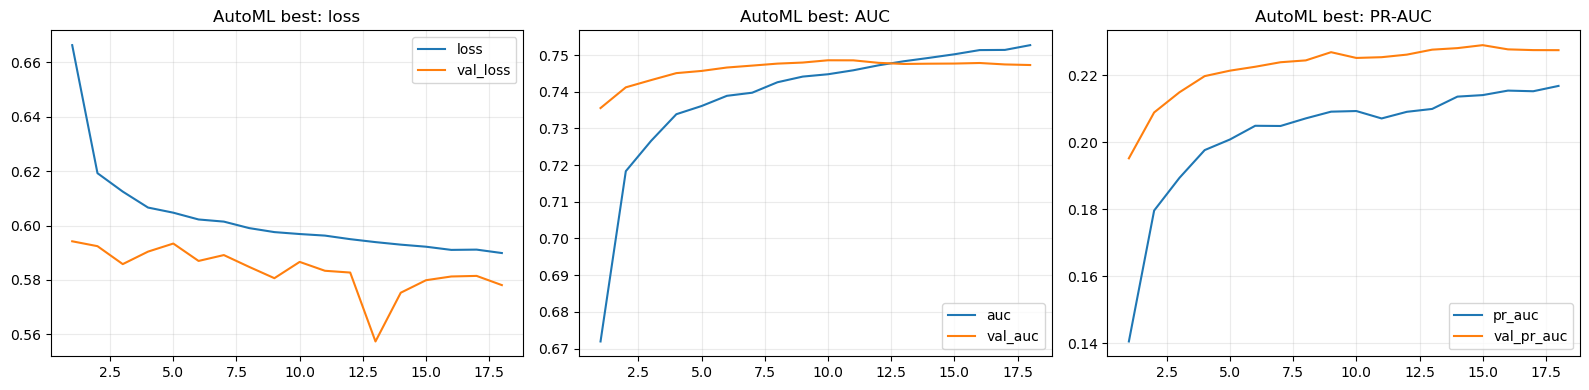

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 18.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 18.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 22: ReduceLROnPlateau reducing learning rat

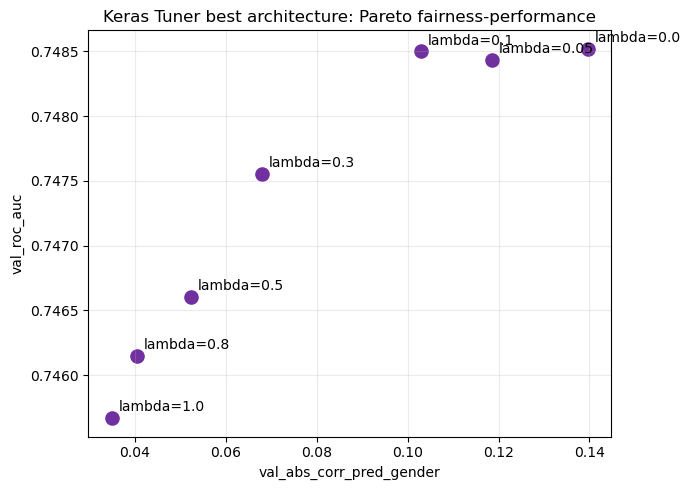

In [15]:
def hp_get(hp, name, default=np.nan):
    try:
        return hp.get(name)
    except Exception:
        return default

def build_tuned_model(hp, fair_lambda=None, model_name="tuned_model"):
    num_layers = hp.Int("num_layers", min_value=1, max_value=4, step=1)
    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 5e-4, 1e-4])
    dense_units = []
    dropout_rates = []
    for i in range(num_layers):
        dense_units.append(hp.Int(f"units_{i}", min_value=16, max_value=128, step=16))
        dropout_rates.append(hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.5, step=0.1))
    return build_custom_layer_model(
        processed_dim=input_dim,
        dense_units=tuple(dense_units),
        dropout_rates=tuple(dropout_rates),
        learning_rate=learning_rate,
        use_batch_norm=False,
        use_layer_norm=True,
        fair_lambda=fair_lambda,
        model_name=model_name,
    )

keras_tuner_trials_with_fairness = pd.DataFrame()
tuner_pareto_results_df = pd.DataFrame()

if kt is not None:
    project_name = "home_credit_aml_v2_critica"
    project_dir = TUNER_DIR / project_name
    if project_dir.exists():
        shutil.rmtree(project_dir)

    tuner = kt.RandomSearch(
        lambda hp: build_tuned_model(hp, fair_lambda=None, model_name="KerasTuner_NoFair"),
        objective=kt.Objective("val_auc", direction="max"),
        max_trials=TUNER_MAX_TRIALS,
        overwrite=True,
        directory=str(TUNER_DIR.resolve()),
        project_name=project_name,
        seed=RANDOM_STATE,
    )

    tuner.search(
        [X_train_keras, X_train_fin_raw],
        y_train_np,
        validation_data=([X_val_keras, X_val_fin_raw], y_val_np),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)],
        verbose=1,
    )

    top_n = min(5, TUNER_MAX_TRIALS)
    best_hps_list = tuner.get_best_hyperparameters(num_trials=top_n)
    best_models = tuner.get_best_models(num_models=top_n)
    trial_rows = []
    for i, (hp, model) in enumerate(zip(best_hps_list, best_models), start=1):
        val_proba = model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        val_eval = evaluate_model(f"keras_tuner_top_{i}", y_val_np, val_proba, s_val_np, threshold, "best_f1_validation")
        num_layers = hp_get(hp, "num_layers")
        units = [hp_get(hp, f"units_{j}") for j in range(int(num_layers))]
        dropout = [hp_get(hp, f"dropout_{j}") for j in range(int(num_layers))]
        trial_rows.append({
            "trial_id": f"top_{i}",
            "lambda_corr": 0.0,
            "num_layers": num_layers,
            "units": json.dumps(units),
            "dropout": json.dumps(dropout),
            "learning_rate": hp_get(hp, "learning_rate"),
            "use_layer_norm": True,
            "val_auc": val_eval["roc_auc"],
            "val_pr_auc": val_eval["pr_auc"],
            "val_corr_pred_gender": val_eval["corr_pred_gender"],
            "val_abs_corr_pred_gender": abs(val_eval["corr_pred_gender"]),
            "val_demographic_parity_gap_score": val_eval["demographic_parity_gap_score"],
            "val_equal_opportunity_gap": val_eval["equal_opportunity_gap"],
        })

    keras_tuner_trials_with_fairness = pd.DataFrame(trial_rows)
    keras_tuner_trials_with_fairness.to_csv(TABLE_DIR / "keras_tuner_trials_with_fairness.csv", index=False)

    plt.figure(figsize=(7, 5))
    plt.scatter(keras_tuner_trials_with_fairness["val_abs_corr_pred_gender"], keras_tuner_trials_with_fairness["val_auc"], s=90, c="#7030A0")
    for _, row in keras_tuner_trials_with_fairness.iterrows():
        plt.annotate(row["trial_id"], (row["val_abs_corr_pred_gender"], row["val_auc"]), textcoords="offset points", xytext=(5, 5))
    plt.xlabel("val_abs_corr_pred_gender")
    plt.ylabel("val_auc")
    plt.title("Keras Tuner trials: AUC vs fairness")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "keras_tuner_trials_auc_vs_fairness.png", dpi=140, bbox_inches="tight")
    plt.show()

    best_hp = best_hps_list[0]
    automl_model = build_tuned_model(best_hp, fair_lambda=None, model_name="AutoML_Best_NoFair")
    history_automl_best = automl_model.fit(
        [X_train_keras, X_train_fin_raw],
        y_train_np,
        validation_data=([X_val_keras, X_val_fin_raw], y_val_np),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=make_callbacks(monitor="val_auc", mode="max", patience=8),
        verbose=1,
    )
    plot_training_history(history_automl_best, "AutoML best", "loss_curve_automl_best.png")
    automl_val_proba = automl_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
    automl_test_proba = automl_model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE).ravel()
    automl_threshold, _ = find_best_threshold(y_val_np, automl_val_proba, metric="f1")
    automl_metrics = evaluate_model("AutoML Keras Tuner", y_test_np, automl_test_proba, s_test_np, automl_threshold, "best_f1_validation")
    automl_metrics["evaluation_scope"] = "full_test"
    results_full_test.append(automl_metrics)

    tuner_pareto_rows = []
    for lambda_corr in lambdas:
        reset_seeds(42)
        tf.keras.backend.clear_session()
        model = build_tuned_model(best_hp, fair_lambda=lambda_corr, model_name=f"AutoML_best_arch_lambda_{lambda_corr}")
        model.fit(
            [X_train_keras, X_train_fin_raw],
            y_train_ext,
            validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
            sample_weight=sample_weight_train,
            epochs=FAIRNESS_EPOCHS,
            batch_size=FAIR_BATCH_SIZE,
            callbacks=make_callbacks(monitor="val_loss", mode="min", patience=5),
            verbose=0,
        )
        val_proba = model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        test_proba = model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        val_eval = evaluate_model(f"AutoML FAIR lambda={lambda_corr}", y_val_np, val_proba, s_val_np, threshold, "best_f1_validation")
        test_eval = evaluate_model(f"AutoML FAIR lambda={lambda_corr}", y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
        tuner_pareto_rows.append({
            "trial_id": f"best_arch_lambda_{lambda_corr}",
            "lambda_corr": lambda_corr,
            "num_layers": hp_get(best_hp, "num_layers"),
            "learning_rate": hp_get(best_hp, "learning_rate"),
            "val_roc_auc": val_eval["roc_auc"],
            "val_pr_auc": val_eval["pr_auc"],
            "val_corr_pred_gender": val_eval["corr_pred_gender"],
            "val_abs_corr_pred_gender": abs(val_eval["corr_pred_gender"]),
            "val_demographic_parity_gap_score": val_eval["demographic_parity_gap_score"],
            "test_roc_auc": test_eval["roc_auc"],
            "test_pr_auc": test_eval["pr_auc"],
            "test_corr_pred_gender": test_eval["corr_pred_gender"],
        })
    tuner_pareto_results_df = pd.DataFrame(tuner_pareto_rows)
    tuner_pareto_results_df.to_csv(TABLE_DIR / "tuner_pareto_results.csv", index=False)

    plt.figure(figsize=(7, 5))
    plt.scatter(tuner_pareto_results_df["val_abs_corr_pred_gender"], tuner_pareto_results_df["val_roc_auc"], s=90, color="#7030A0")
    for _, row in tuner_pareto_results_df.iterrows():
        plt.annotate(f"lambda={row['lambda_corr']}", (row["val_abs_corr_pred_gender"], row["val_roc_auc"]), textcoords="offset points", xytext=(5, 5))
    plt.xlabel("val_abs_corr_pred_gender")
    plt.ylabel("val_roc_auc")
    plt.title("Keras Tuner best architecture: Pareto fairness-performance")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "keras_tuner_pareto_precision_vs_fair_dependency.png", dpi=140, bbox_inches="tight")
    plt.show()
else:
    keras_tuner_trials_with_fairness.to_csv(TABLE_DIR / "keras_tuner_trials_with_fairness.csv", index=False)
    tuner_pareto_results_df.to_csv(TABLE_DIR / "tuner_pareto_results.csv", index=False)
    for filename, title in [
        ("keras_tuner_trials_auc_vs_fairness.png", "Keras Tuner no disponible"),
        ("keras_tuner_pareto_precision_vs_fair_dependency.png", "Keras Tuner no disponible"),
        ("loss_curve_automl_best.png", "Keras Tuner no disponible"),
    ]:
        plt.figure(figsize=(6, 4))
        plt.text(0.5, 0.5, title, ha="center", va="center")
        plt.axis("off")
        plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
        plt.show()


## 14. Capa custom adaptativa

La auditoria muestra que `CREDIT_INCOME_RATIO` puede saturarse demasiado con `alpha=1`. La capa adaptativa usa alphas distintos por ratio:

- annuity / income: 1.0;
- credit / income: 0.10;
- annuity / credit: 5.0;
- goods / credit: 1.0.

Asi cada ratio se satura segun su escala economica.


,ratio_name,method,alpha,raw_median,raw_p95,raw_p99,raw_max,sat_median,sat_p95,sat_p99,sat_max,pct_sat_above_0_95,pct_sat_above_0_99
0,ANNUITY_INCOME_RAW,original_alpha_1,1.0000,0.1626,0.3549,0.4845,1.5706,0.1612,0.3407,0.4498,0.9171,0.0000,0.0000
1,ANNUITY_INCOME_RAW,adaptive_alpha,1.0000,0.1626,0.3549,0.4845,1.5706,0.1612,0.3407,0.4498,0.9171,0.0000,0.0000
2,CREDIT_INCOME_RAW,original_alpha_1,1.0000,3.2531,9.1229,13.0136,49.2272,0.9970,1.0000,1.0000,1.0000,0.7976,0.6230
3,CREDIT_INCOME_RAW,adaptive_alpha,0.1000,3.2531,9.1229,13.0136,49.2272,0.3143,0.7222,0.8621,0.9999,0.0014,0.0002
4,ANNUITY_CREDIT_RAW,original_alpha_1,1.0000,0.0500,0.1050,0.1143,0.1581,0.0500,0.1046,0.1138,0.1568,0.0000,0.0000
5,ANNUITY_CREDIT_RAW,adaptive_alpha,5.0000,0.0500,0.1050,0.1143,0.1581,0.2449,0.4816,0.5164,0.6587,0.0000,0.0000
6,GOODS_CREDIT_RAW,original_alpha_1,1.0000,0.8938,1.0000,1.0000,6.6667,0.7133,0.7616,0.7616,1.0000,0.0008,0.0002
7,GOODS_CREDIT_RAW,adaptive_alpha,1.0000,0.8938,1.0000,1.0000,6.6667,0.7133,0.7616,0.7616,1.0000,0.0008,0.0002


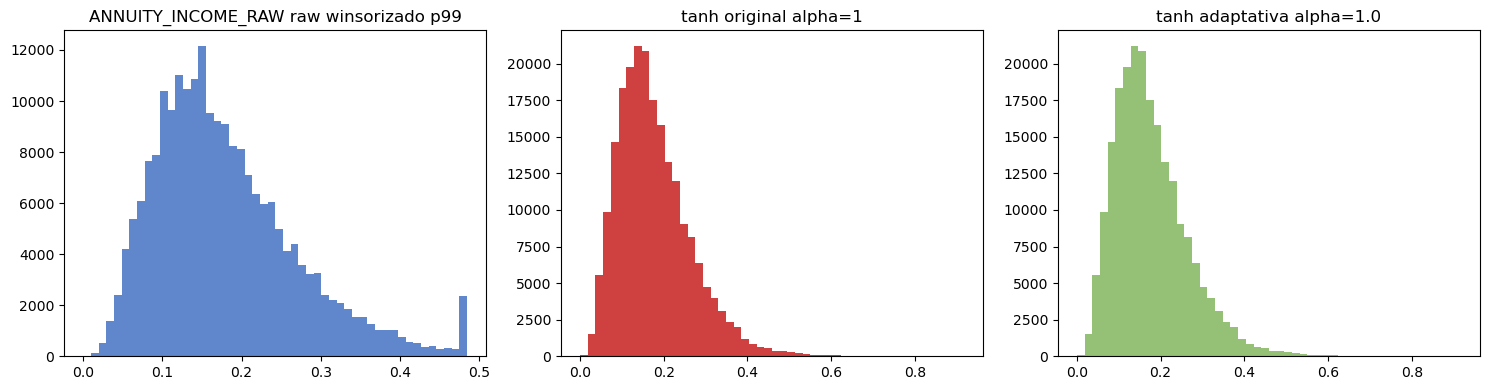

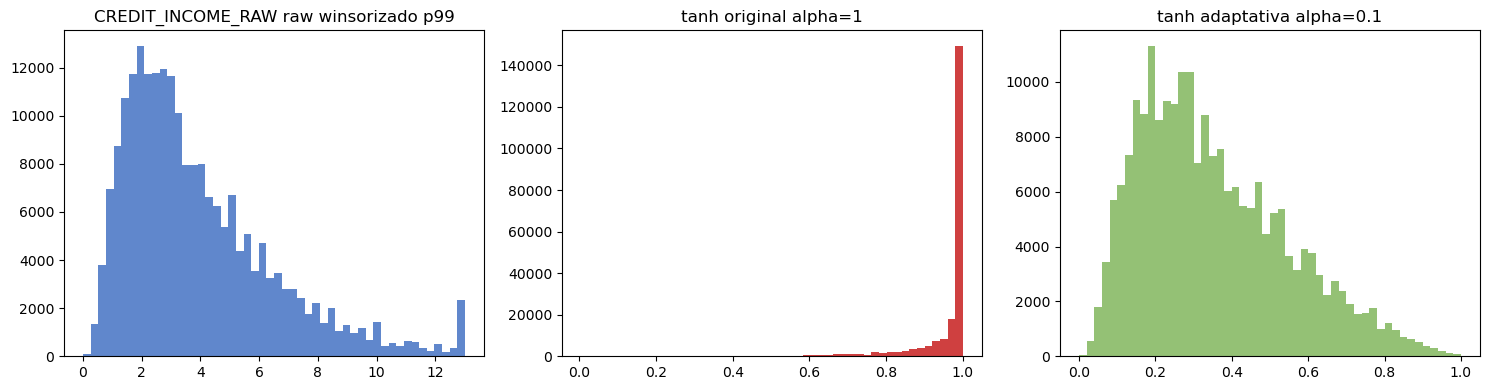

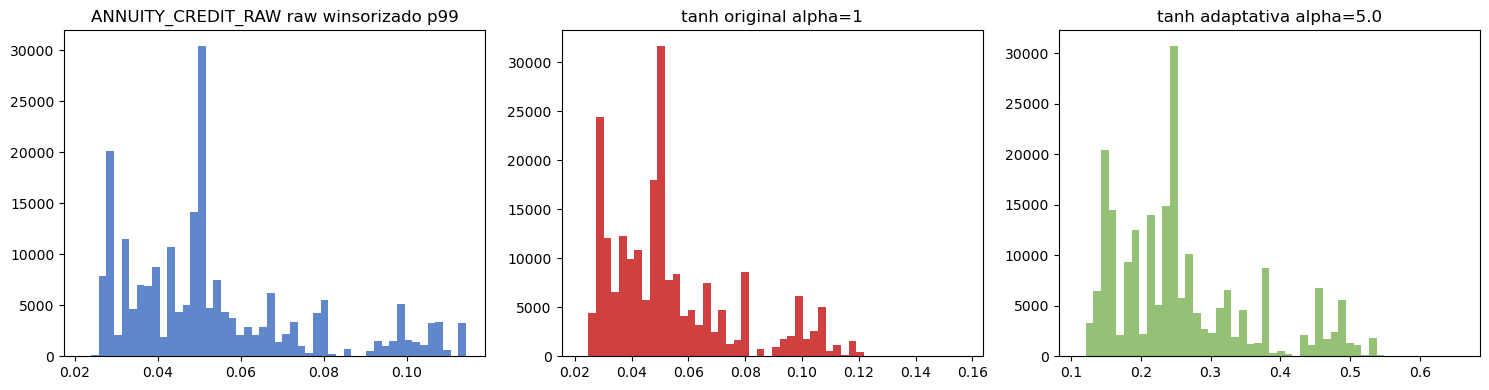

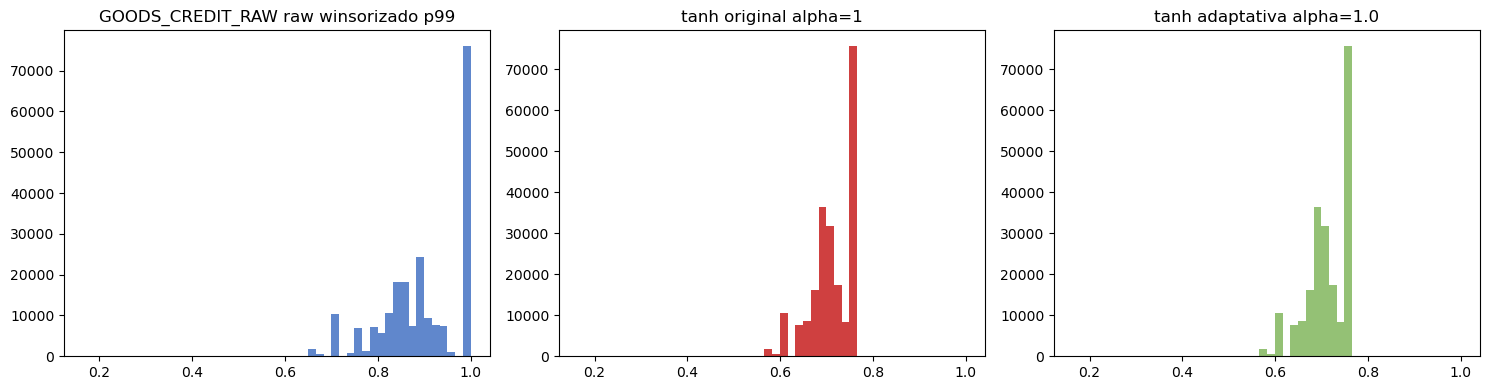

In [16]:
SEEDS_ADAPTIVE_FAIR_SWEEP = [42] if FAST_MODE else [42, 123, 2026]
lambdas_adaptive = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]


class DebtRatioAdaptiveSaturationLayer(keras.layers.Layer):
    def __init__(
        self,
        units=8,
        alpha_annuity_income=1.0,
        alpha_credit_income=0.10,
        alpha_annuity_credit=5.0,
        alpha_goods_credit=1.0,
        epsilon=1e-6,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.alpha_annuity_income = alpha_annuity_income
        self.alpha_credit_income = alpha_credit_income
        self.alpha_annuity_credit = alpha_annuity_credit
        self.alpha_goods_credit = alpha_goods_credit
        self.units = units
        self.epsilon = epsilon
        self.projection = layers.Dense(units, activation="relu")

    def call(self, inputs):
        income = inputs[:, 0:1]
        annuity = inputs[:, 1:2]
        credit = inputs[:, 2:3]
        goods = inputs[:, 3:4]

        annuity_income = annuity / (income + self.epsilon)
        credit_income = credit / (income + self.epsilon)
        annuity_credit = annuity / (credit + self.epsilon)
        goods_credit = goods / (credit + self.epsilon)

        ratios_sat = tf.concat(
            [
                tf.math.tanh(self.alpha_annuity_income * annuity_income),
                tf.math.tanh(self.alpha_credit_income * credit_income),
                tf.math.tanh(self.alpha_annuity_credit * annuity_credit),
                tf.math.tanh(self.alpha_goods_credit * goods_credit),
            ],
            axis=-1,
        )
        return self.projection(ratios_sat)

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha_annuity_income": self.alpha_annuity_income,
            "alpha_credit_income": self.alpha_credit_income,
            "alpha_annuity_credit": self.alpha_annuity_credit,
            "alpha_goods_credit": self.alpha_goods_credit,
            "units": self.units,
            "epsilon": self.epsilon,
        })
        return config


ADAPTIVE_ALPHAS = {
    "ANNUITY_INCOME_RAW": 1.0,
    "CREDIT_INCOME_RAW": 0.10,
    "ANNUITY_CREDIT_RAW": 5.0,
    "GOODS_CREDIT_RAW": 1.0,
}


def build_adaptive_custom_layer_model(
    processed_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    fair_lambda=None,
    model_name="adaptive_custom_model",
):
    processed_input = keras.Input(shape=(processed_dim,), name="processed_input")
    raw_financial_input = keras.Input(shape=(4,), name="raw_financial_input")
    financial_repr = DebtRatioAdaptiveSaturationLayer(name="debt_ratio_adaptive_saturation")(raw_financial_input)
    x = layers.Concatenate(name="concat_processed_adaptive_financial")([processed_input, financial_repr])
    for i, units in enumerate(dense_units):
        x = layers.Dense(units, activation="relu", name=f"dense_{i+1}")(x)
        x = layers.LayerNormalization(name=f"layer_norm_{i+1}")(x)
        dropout = dropout_rates[i] if i < len(dropout_rates) else dropout_rates[-1]
        x = layers.Dropout(dropout, name=f"dropout_{i+1}")(x)
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)
    model = keras.Model([processed_input, raw_financial_input], output, name=model_name)
    compile_model(model, fair_lambda=fair_lambda, learning_rate=learning_rate)
    return model


def raw_financial_ratios_from_matrix(raw_matrix, eps=1e-6):
    income = raw_matrix[:, 0]
    annuity = raw_matrix[:, 1]
    credit = raw_matrix[:, 2]
    goods = raw_matrix[:, 3]
    return pd.DataFrame({
        "ANNUITY_INCOME_RAW": annuity / (income + eps),
        "CREDIT_INCOME_RAW": credit / (income + eps),
        "ANNUITY_CREDIT_RAW": annuity / (credit + eps),
        "GOODS_CREDIT_RAW": goods / (credit + eps),
    }).replace([np.inf, -np.inf], np.nan)


raw_ratios_train_v4 = raw_financial_ratios_from_matrix(X_train_fin_raw)
saturation_rows = []
for ratio_name in raw_ratios_train_v4.columns:
    raw = raw_ratios_train_v4[ratio_name].dropna()
    for method, alpha in [("original_alpha_1", 1.0), ("adaptive_alpha", ADAPTIVE_ALPHAS[ratio_name])]:
        sat = np.tanh(alpha * raw)
        saturation_rows.append({
            "ratio_name": ratio_name,
            "method": method,
            "alpha": alpha,
            "raw_median": raw.median(),
            "raw_p95": raw.quantile(0.95),
            "raw_p99": raw.quantile(0.99),
            "raw_max": raw.max(),
            "sat_median": np.median(sat),
            "sat_p95": np.percentile(sat, 95),
            "sat_p99": np.percentile(sat, 99),
            "sat_max": np.max(sat),
            "pct_sat_above_0_95": float(np.mean(sat > 0.95)),
            "pct_sat_above_0_99": float(np.mean(sat > 0.99)),
        })

ratio_saturation_original_vs_adaptive = pd.DataFrame(saturation_rows)
ratio_saturation_original_vs_adaptive.to_csv(TABLE_DIR / "ratio_saturation_original_vs_adaptive.csv", index=False)
display(ratio_saturation_original_vs_adaptive)

plot_map = {
    "ANNUITY_INCOME_RAW": "saturation_comparison_annuity_income.png",
    "CREDIT_INCOME_RAW": "saturation_comparison_credit_income.png",
    "ANNUITY_CREDIT_RAW": "saturation_comparison_annuity_credit.png",
    "GOODS_CREDIT_RAW": "saturation_comparison_goods_credit.png",
}
for ratio_name, filename in plot_map.items():
    raw = raw_ratios_train_v4[ratio_name].dropna()
    raw_w = raw.clip(upper=raw.quantile(0.99))
    sat_original = np.tanh(raw)
    sat_adaptive = np.tanh(ADAPTIVE_ALPHAS[ratio_name] * raw)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(raw_w, bins=50, color="#4472C4", alpha=0.85)
    axes[0].set_title(f"{ratio_name} raw winsorizado p99")
    axes[1].hist(sat_original, bins=50, color="#C00000", alpha=0.75)
    axes[1].set_title("tanh original alpha=1")
    axes[2].hist(sat_adaptive, bins=50, color="#70AD47", alpha=0.75)
    axes[2].set_title(f"tanh adaptativa alpha={ADAPTIVE_ALPHAS[ratio_name]}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()


## 15. Sweep adaptativo multi-seed

Se repite el sweep de `lambda_corr` con la capa adaptativa y varias semillas. La seleccion vuelve a usar validation agregada.


In [17]:
adaptive_seed_val_rows = []
adaptive_seed_test_rows = []

for seed in SEEDS_ADAPTIVE_FAIR_SWEEP:
    for lambda_corr in lambdas_adaptive:
        print(f"Entrenando adaptativo seed={seed}, lambda={lambda_corr}...")
        reset_seeds(seed)
        tf.keras.backend.clear_session()
        model = build_adaptive_custom_layer_model(
            processed_dim=input_dim,
            dense_units=(64, 32),
            dropout_rates=(0.25, 0.20),
            learning_rate=1e-3,
            fair_lambda=lambda_corr,
            model_name=f"Adaptive_Fair_seed_{seed}_lambda_{lambda_corr}",
        )
        assert_no_batchnorm(model)
        model.fit(
            [X_train_keras, X_train_fin_raw],
            y_train_ext,
            validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
            sample_weight=sample_weight_train,
            epochs=FAIRNESS_EPOCHS,
            batch_size=FAIR_BATCH_SIZE,
            callbacks=make_callbacks(monitor="val_loss", mode="min", patience=5),
            verbose=0,
        )
        val_proba = model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        test_proba = model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE, verbose=0).ravel()
        threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        val_metrics = evaluate_model("adaptive_seed_validation", y_val_np, val_proba, s_val_np, threshold, "best_f1_validation")
        test_metrics = evaluate_model("adaptive_seed_test", y_test_np, test_proba, s_test_np, threshold, "best_f1_validation")
        adaptive_seed_val_rows.append({
            "seed": seed,
            "lambda_corr": lambda_corr,
            "split": "validation",
            "roc_auc": val_metrics["roc_auc"],
            "pr_auc": val_metrics["pr_auc"],
            "corr_pred_gender": val_metrics["corr_pred_gender"],
            "abs_corr_pred_gender": abs(val_metrics["corr_pred_gender"]),
            "demographic_parity_gap_score": val_metrics["demographic_parity_gap_score"],
            "equal_opportunity_gap": val_metrics["equal_opportunity_gap"],
            "fpr_gap": val_metrics["fpr_gap"],
            "precision": val_metrics["precision"],
            "recall": val_metrics["recall"],
            "f1": val_metrics["f1"],
        })
        adaptive_seed_test_rows.append({
            "seed": seed,
            "lambda_corr": lambda_corr,
            "split": "test",
            "roc_auc": test_metrics["roc_auc"],
            "pr_auc": test_metrics["pr_auc"],
            "corr_pred_gender": test_metrics["corr_pred_gender"],
            "abs_corr_pred_gender": abs(test_metrics["corr_pred_gender"]),
            "demographic_parity_gap_score": test_metrics["demographic_parity_gap_score"],
            "equal_opportunity_gap": test_metrics["equal_opportunity_gap"],
            "fpr_gap": test_metrics["fpr_gap"],
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
        })

lambda_adaptive_seed_results_validation = pd.DataFrame(adaptive_seed_val_rows)
lambda_adaptive_seed_results_test = pd.DataFrame(adaptive_seed_test_rows)
lambda_adaptive_seed_results_validation.to_csv(TABLE_DIR / "lambda_adaptive_seed_results_validation.csv", index=False)
lambda_adaptive_seed_results_test.to_csv(TABLE_DIR / "lambda_adaptive_seed_results_test.csv", index=False)

val_summary_adapt = lambda_adaptive_seed_results_validation.groupby("lambda_corr").agg(
    val_roc_auc_mean=("roc_auc", "mean"),
    val_roc_auc_std=("roc_auc", "std"),
    val_pr_auc_mean=("pr_auc", "mean"),
    val_pr_auc_std=("pr_auc", "std"),
    val_abs_corr_mean=("abs_corr_pred_gender", "mean"),
    val_abs_corr_std=("abs_corr_pred_gender", "std"),
    val_demographic_parity_gap_mean=("demographic_parity_gap_score", "mean"),
    val_demographic_parity_gap_std=("demographic_parity_gap_score", "std"),
).reset_index()
test_summary_adapt = lambda_adaptive_seed_results_test.groupby("lambda_corr").agg(
    test_roc_auc_mean=("roc_auc", "mean"),
    test_roc_auc_std=("roc_auc", "std"),
    test_abs_corr_mean=("abs_corr_pred_gender", "mean"),
    test_abs_corr_std=("abs_corr_pred_gender", "std"),
).reset_index()
lambda_adaptive_sweep_summary_by_seed = val_summary_adapt.merge(test_summary_adapt, on="lambda_corr", how="left")
lambda_adaptive_sweep_summary_by_seed["n_runs"] = len(SEEDS_ADAPTIVE_FAIR_SWEEP)
lambda_adaptive_sweep_summary_by_seed.to_csv(TABLE_DIR / "lambda_adaptive_sweep_summary_by_seed.csv", index=False)
display(lambda_adaptive_sweep_summary_by_seed)

eligible = lambda_adaptive_sweep_summary_by_seed[
    lambda_adaptive_sweep_summary_by_seed["val_abs_corr_mean"] < 0.05
].copy()
if not eligible.empty:
    max_auc = eligible["val_roc_auc_mean"].max()
    practical_ties = eligible[eligible["val_roc_auc_mean"] >= max_auc - 0.001]
    selected_adaptive_lambda_row = practical_ties.sort_values("lambda_corr").iloc[0]
    best_lambda_adaptive_selection_reason = (
        "Seleccionada con validation agregado: abs corr < 0.05, AUC dentro de empate practico de 0.001 y lambda menor."
    )
else:
    tmp = lambda_adaptive_sweep_summary_by_seed.copy()
    tmp["score"] = tmp["val_roc_auc_mean"] - 0.05 * tmp["val_abs_corr_mean"]
    selected_adaptive_lambda_row = tmp.sort_values("score", ascending=False).iloc[0]
    best_lambda_adaptive_selection_reason = (
        "Ninguna lambda cumple abs corr < 0.05; se maximiza val_roc_auc_mean - 0.05 * val_abs_corr_mean."
    )

best_lambda_adaptive = float(selected_adaptive_lambda_row["lambda_corr"])
best_lambda_adaptive_selection = pd.DataFrame([{
    "best_lambda_adaptive": best_lambda_adaptive,
    "selection_reason": best_lambda_adaptive_selection_reason,
    "val_roc_auc_mean": selected_adaptive_lambda_row["val_roc_auc_mean"],
    "val_abs_corr_mean": selected_adaptive_lambda_row["val_abs_corr_mean"],
}])
best_lambda_adaptive_selection.to_csv(TABLE_DIR / "best_lambda_adaptive_selection.csv", index=False)
display(best_lambda_adaptive_selection)


Entrenando adaptativo seed=42, lambda=0.0...

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 19.
Entrenando adaptativo seed=42, lambda=0.1...

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.
Entrenando adaptativo seed=42, lambda=0.3...

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.
Entrenando adaptativo seed=42, lambda=0.5...

Epoch 14: ReduceLR

,lambda_corr,val_roc_auc_mean,val_roc_auc_std,val_pr_auc_mean,val_pr_auc_std,val_abs_corr_mean,val_abs_corr_std,val_demographic_parity_gap_mean,val_demographic_parity_gap_std,test_roc_auc_mean,test_roc_auc_std,test_abs_corr_mean,test_abs_corr_std,n_runs
0,0.0000,0.7493,0.0008,0.2308,0.0027,0.1377,0.0008,0.0594,0.0014,0.7526,0.0009,0.1354,0.0015,3
1,0.1000,0.7491,0.0008,0.2304,0.0024,0.1033,0.0023,0.0441,0.0008,0.7525,0.0008,0.1012,0.0028,3
2,0.3000,0.7480,0.0006,0.2295,0.0023,0.0686,0.0021,0.0290,0.0009,0.7520,0.0005,0.0671,0.0023,3
3,0.5000,0.7472,0.0005,0.2289,0.0021,0.0526,0.0021,0.0223,0.0005,0.7514,0.0003,0.0513,0.0024,3
4,0.8000,0.7465,0.0005,0.2289,0.0023,0.0391,0.0008,0.0167,0.0004,0.7510,0.0002,0.0380,0.0004,3
5,1.0000,0.7463,0.0005,0.2287,0.0019,0.0343,0.0010,0.0147,0.0004,0.7508,0.0002,0.0330,0.0004,3


,best_lambda_adaptive,selection_reason,val_roc_auc_mean,val_abs_corr_mean
0,0.8000,Seleccionada con validation agregado: abs corr...,0.7465,0.0391


## 16. Seleccion final de capa y lambda sin mirar test

La decision final entre capa original y adaptativa usa:

- metricas de validation;
- auditoria de saturacion en train;
- restriccion practica de fairness.

El test no participa en esta decision.


In [18]:
def select_final_custom_layer_model(
    original_val_metrics,
    adaptive_val_metrics,
    saturation_summary,
    max_auc_loss=0.005,
    max_abs_corr=0.05,
):
    credit_rows = saturation_summary[saturation_summary["ratio_name"] == "CREDIT_INCOME_RAW"]
    original_sat = float(
        credit_rows.loc[credit_rows["method"] == "original_alpha_1", "pct_sat_above_0_99"].iloc[0]
    )
    adaptive_sat = float(
        credit_rows.loc[credit_rows["method"] == "adaptive_alpha", "pct_sat_above_0_99"].iloc[0]
    )
    saturation_reduced = adaptive_sat < original_sat * 0.75 or (original_sat - adaptive_sat) >= 0.10

    best_val_auc = max(original_val_metrics["roc_auc"], adaptive_val_metrics["roc_auc"])
    adaptive_auc_loss = best_val_auc - adaptive_val_metrics["roc_auc"]
    adaptive_fair_ok = abs(adaptive_val_metrics["corr_pred_gender"]) < max_abs_corr

    rows = []
    for name, layer_type, metrics, sat_value in [
        ("FAIR candidato capa original", "original_common_tanh", original_val_metrics, original_sat),
        ("FAIR candidato capa adaptativa", "adaptive_tanh", adaptive_val_metrics, adaptive_sat),
    ]:
        rows.append({
            "candidate_model": name,
            "custom_layer_type": layer_type,
            "val_roc_auc": metrics["roc_auc"],
            "val_pr_auc": metrics["pr_auc"],
            "val_abs_corr_pred_gender": abs(metrics["corr_pred_gender"]),
            "val_demographic_parity_gap_score": metrics["demographic_parity_gap_score"],
            "credit_income_pct_sat_above_0_99": sat_value,
            "selected": False,
            "selection_reason": "",
        })

    if saturation_reduced and adaptive_auc_loss <= max_auc_loss and adaptive_fair_ok:
        selected_layer = "adaptive"
        reason = (
            "Se elige capa adaptativa: reduce saturacion de CREDIT_INCOME_RATIO, "
            "no pierde mas de 0.005 AUC en validation y cumple abs(corr)<0.05."
        )
    elif adaptive_auc_loss > max_auc_loss:
        selected_layer = "original"
        reason = (
            "Se mantiene capa original: la adaptativa pierde mas de 0.005 ROC-AUC en validation."
        )
    elif not adaptive_fair_ok:
        selected_layer = "original"
        reason = (
            "Se mantiene capa original: la adaptativa no cumple abs(corr_pred_gender_val)<0.05."
        )
    else:
        selected_layer = "original"
        reason = (
            "Se mantiene capa original: la mejora de saturacion no es suficientemente clara."
        )

    result = pd.DataFrame(rows)
    result.loc[result["custom_layer_type"].eq("adaptive_tanh" if selected_layer == "adaptive" else "original_common_tanh"), "selected"] = True
    result["selection_reason"] = reason
    return selected_layer, reason, result


reset_seeds(42)
tf.keras.backend.clear_session()
adaptive_fair_candidate = build_adaptive_custom_layer_model(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    fair_lambda=best_lambda_adaptive,
    model_name="FAIR_NN_Adaptive_CustomLayer_candidate",
)
assert_no_batchnorm(adaptive_fair_candidate)
adaptive_fair_candidate.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_ext,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
    sample_weight=sample_weight_train,
    epochs=MAX_EPOCHS,
    batch_size=FAIR_BATCH_SIZE,
    callbacks=make_callbacks(monitor="val_loss", mode="min", patience=8),
    verbose=1,
)
adaptive_candidate_val_proba = adaptive_fair_candidate.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
adaptive_candidate_val_threshold, _ = find_best_threshold(y_val_np, adaptive_candidate_val_proba, metric="f1")
adaptive_candidate_val_metrics = evaluate_model(
    "FAIR candidato capa adaptativa",
    y_val_np,
    adaptive_candidate_val_proba,
    s_val_np,
    adaptive_candidate_val_threshold,
    "best_f1_validation",
)

original_candidate_val_metrics = evaluate_model(
    "FAIR candidato capa original",
    y_val_np,
    y_val_proba_fair,
    s_val_np,
    best_threshold_fair,
    "best_f1_validation",
)

final_layer_choice, final_layer_selection_reason, final_model_selection_validation_only = select_final_custom_layer_model(
    original_candidate_val_metrics,
    adaptive_candidate_val_metrics,
    ratio_saturation_original_vs_adaptive,
    max_auc_loss=0.005,
    max_abs_corr=0.05,
)
final_model_selection_validation_only.to_csv(TABLE_DIR / "final_model_selection_validation_only.csv", index=False)
display(final_model_selection_validation_only)



Epoch 1/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6723 - val_loss: 0.6091 - learning_rate: 0.0010
Epoch 2/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6251 - val_loss: 0.6041 - learning_rate: 0.0010
Epoch 3/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6151 - val_loss: 0.6022 - learning_rate: 0.0010
Epoch 4/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6103 - val_loss: 0.6010 - learning_rate: 0.0010
Epoch 5/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6078 - val_loss: 0.6000 - learning_rate: 0.0010
Epoch 6/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6049 - val_loss: 0.5997 - learning_rate: 0.0010
Epoch 7/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6039 - val_loss: 0.5993 - learning_rate: 0.0010
Epoch 8/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6023 - val_loss: 0.5988 - learning_rate: 0.0010
Epoch 9/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6015 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 10/8

,candidate_model,custom_layer_type,val_roc_auc,val_pr_auc,val_abs_corr_pred_gender,val_demographic_parity_gap_score,credit_income_pct_sat_above_0_99,selected,selection_reason
0,FAIR candidato capa original,original_common_tanh,0.7470,0.2301,0.0381,0.0156,0.6230,False,Se elige capa adaptativa: reduce saturacion de...
1,FAIR candidato capa adaptativa,adaptive_tanh,0.7469,0.2309,0.0439,0.0177,0.0002,True,Se elige capa adaptativa: reduce saturacion de...


## 17. Reentrenamiento final Base vs FAIR

Una vez elegidos capa y lambda, se reentrenan dos modelos finales con la misma arquitectura:

- `Base NN Final sin FAIR`: lambda = 0;
- `FAIR NN Final`: lambda seleccionada.

Asi la comparacion es limpia: la diferencia principal es la restriccion FAIR.


Epoch 1/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.6938 - loss: 0.6516 - pr_auc: 0.1564 - val_auc: 0.7393 - val_loss: 0.5817 - val_pr_auc: 0.2115 - learning_rate: 0.0010
Epoch 2/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7268 - loss: 0.6129 - pr_auc: 0.1893 - val_auc: 0.7439 - val_loss: 0.5841 - val_pr_auc: 0.2199 - learning_rate: 0.0010
Epoch 3/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7339 - loss: 0.6060 - pr_auc: 0.2003 - val_auc: 0.7460 - val_loss: 0.5798 - val_pr_auc: 0.2239 - learning_rate: 0.0010
Epoch 4/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7381 - loss: 0.6026 - pr_auc: 0.2052 - val_auc: 0.7471 - val_loss: 0.5764 - val_pr_auc: 0.2269 - learning_rate: 0.0010
Epoch 5/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7410 - loss: 0.6000 - pr_auc: 0.2093 - val_auc: 0.7482 - val_loss: 0.5744 - val_pr_auc: 0.2300 - learning_rate: 0.0010
Epoch 6/80
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7432 - loss: 0.5984 - pr_auc: 0.2117 - 

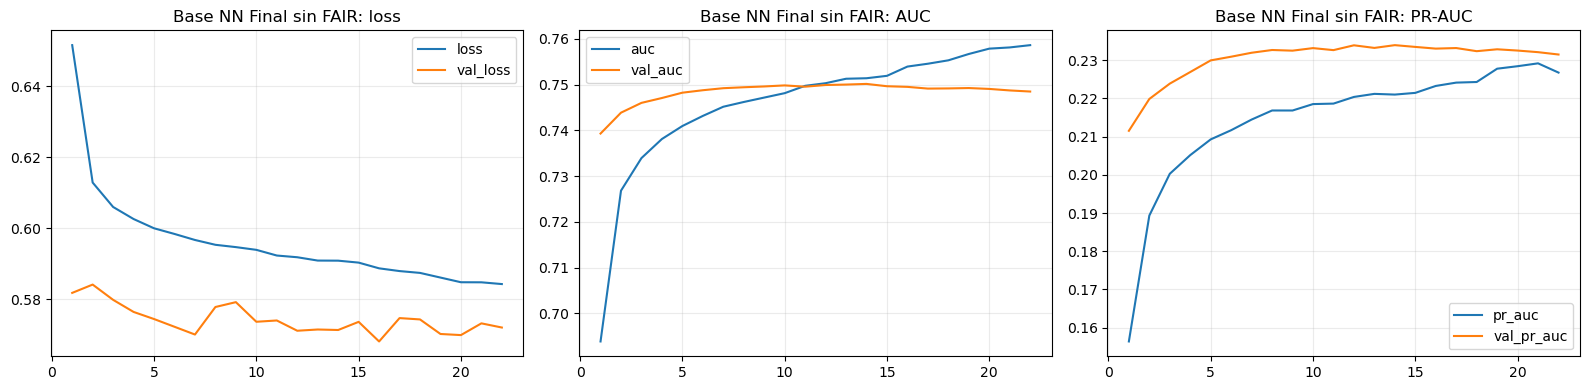

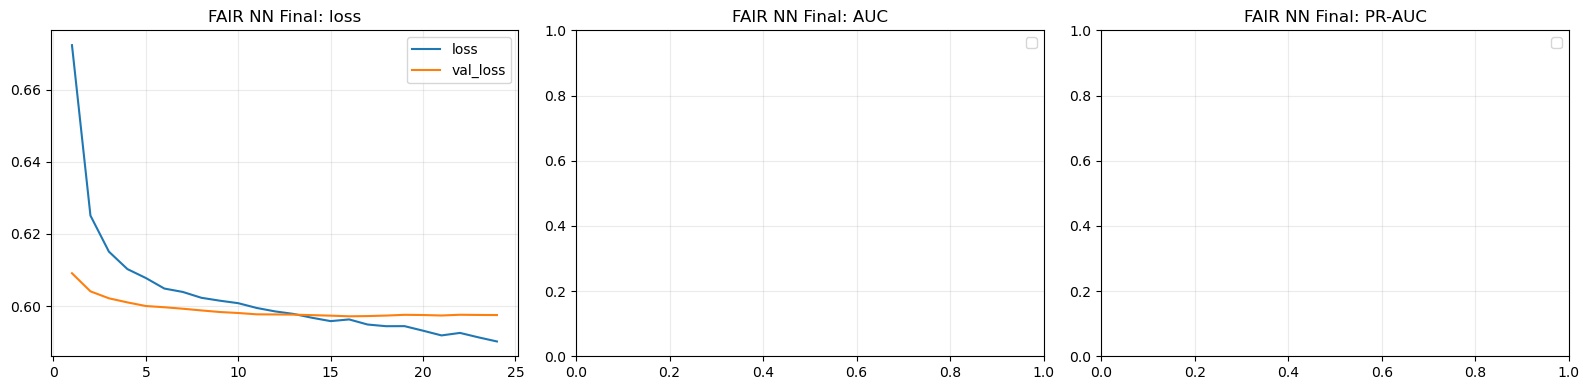

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,lambda_corr,evaluation_scope
0,Base NN Final sin FAIR,best_f1_validation,0.6500,0.8437,0.6526,0.7537,0.2407,0.1958,0.2379,0.4248,0.3050,37335,5068,2142,1582,0.4141,0.0807,0.1438,0.0590,0.0817,0.1175,0.0686,0.0000,full_test
1,FAIR NN Final,best_f1_validation,0.6600,0.8433,0.6481,0.7515,0.2397,0.2014,0.2345,0.4154,0.2997,37352,5051,2177,1547,0.4225,0.0807,0.0428,0.0174,0.0430,0.0435,0.0335,0.8000,full_test


In [19]:
if final_layer_choice == "adaptive":
    final_builder = build_adaptive_custom_layer_model
    final_custom_layer_type = "adaptive_tanh"
    final_lambda = best_lambda_adaptive
else:
    final_builder = build_custom_layer_model
    final_custom_layer_type = "original_common_tanh"
    final_lambda = best_lambda_fair

reset_seeds(42)
tf.keras.backend.clear_session()
base_final_model = final_builder(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    fair_lambda=None,
    model_name="Base_NN_Final_sin_FAIR",
)
assert_no_batchnorm(base_final_model)
history_base_final = base_final_model.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_np,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_np),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks(monitor="val_auc", mode="max", patience=8),
    verbose=1,
)

reset_seeds(42)
tf.keras.backend.clear_session()
fair_final_model = final_builder(
    processed_dim=input_dim,
    dense_units=(64, 32),
    dropout_rates=(0.25, 0.20),
    learning_rate=1e-3,
    fair_lambda=final_lambda,
    model_name="FAIR_NN_Final",
)
assert_no_batchnorm(fair_final_model)
history_fair_final = fair_final_model.fit(
    [X_train_keras, X_train_fin_raw],
    y_train_ext,
    validation_data=([X_val_keras, X_val_fin_raw], y_val_ext, sample_weight_val),
    sample_weight=sample_weight_train,
    epochs=MAX_EPOCHS,
    batch_size=FAIR_BATCH_SIZE,
    callbacks=make_callbacks(monitor="val_loss", mode="min", patience=8),
    verbose=1,
)

plot_training_history(history_base_final, "Base NN Final sin FAIR", "loss_curve_base_final_no_fair.png")
plot_training_history(history_fair_final, "FAIR NN Final", "loss_curve_fair_final.png")

y_val_proba_base_final = base_final_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
y_test_proba_base_final = base_final_model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE).ravel()
y_val_proba_fair_final = fair_final_model.predict([X_val_keras, X_val_fin_raw], batch_size=BATCH_SIZE).ravel()
y_test_proba_fair_final = fair_final_model.predict([X_test_keras, X_test_fin_raw], batch_size=BATCH_SIZE).ravel()

best_threshold_base_final, _ = find_best_threshold(y_val_np, y_val_proba_base_final, metric="f1")
best_threshold_fair_final, _ = find_best_threshold(y_val_np, y_val_proba_fair_final, metric="f1")

base_final_test_metrics = evaluate_model(
    "Base NN Final sin FAIR",
    y_test_np,
    y_test_proba_base_final,
    s_test_np,
    best_threshold_base_final,
    "best_f1_validation",
)
fair_final_test_metrics = evaluate_model(
    "FAIR NN Final",
    y_test_np,
    y_test_proba_fair_final,
    s_test_np,
    best_threshold_fair_final,
    "best_f1_validation",
)
base_final_test_metrics["lambda_corr"] = 0.0
fair_final_test_metrics["lambda_corr"] = final_lambda
base_final_test_metrics["evaluation_scope"] = "full_test"
fair_final_test_metrics["evaluation_scope"] = "full_test"
display(pd.DataFrame([base_final_test_metrics, fair_final_test_metrics]))


## 18. Bootstrap final Base vs FAIR

Las diferencias entre modelos pueden ser pequenas, asi que se recalculan intervalos de confianza sobre el par final reentrenado.


In [20]:
def _fairness_gap_metrics(y_true, y_proba, sensitive, threshold):
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)
    sensitive = np.asarray(sensitive).astype(int)
    male = sensitive == 1
    female = sensitive == 0
    demographic_gap = abs(np.mean(y_proba[male]) - np.mean(y_proba[female])) if male.sum() and female.sum() else np.nan
    tpr_m, fpr_m = _tpr_fpr_by_group(y_true, y_pred, sensitive, 1)
    tpr_f, fpr_f = _tpr_fpr_by_group(y_true, y_pred, sensitive, 0)
    eq_opp = abs(tpr_m - tpr_f) if pd.notna(tpr_m) and pd.notna(tpr_f) else np.nan
    fpr_gap = abs(fpr_m - fpr_f) if pd.notna(fpr_m) and pd.notna(fpr_f) else np.nan
    return demographic_gap, eq_opp, fpr_gap


def compute_bootstrap_base_vs_fair_final(
    y_test,
    y_test_proba_base_final,
    y_test_proba_fair_final,
    s_test,
    threshold_base,
    threshold_fair,
    n_boot=500,
    seed=42,
):
    rng = np.random.default_rng(seed)
    y_test = np.asarray(y_test).astype(int)
    s_test = np.asarray(s_test).astype(int)
    base_p = np.asarray(y_test_proba_base_final).astype(float)
    fair_p = np.asarray(y_test_proba_fair_final).astype(float)
    rows = []
    values = {
        ("roc_auc", "Base"): [],
        ("roc_auc", "FAIR"): [],
        ("pr_auc", "Base"): [],
        ("pr_auc", "FAIR"): [],
        ("abs_corr_pred_gender", "Base"): [],
        ("abs_corr_pred_gender", "FAIR"): [],
        ("demographic_parity_gap_score", "Base"): [],
        ("demographic_parity_gap_score", "FAIR"): [],
        ("equal_opportunity_gap", "Base"): [],
        ("equal_opportunity_gap", "FAIR"): [],
        ("fpr_gap", "Base"): [],
        ("fpr_gap", "FAIR"): [],
        ("delta_roc_auc_fair_minus_base", "FAIR - Base"): [],
        ("delta_pr_auc_fair_minus_base", "FAIR - Base"): [],
        ("delta_abs_corr_fair_minus_base", "FAIR - Base"): [],
        ("delta_demographic_parity_gap_fair_minus_base", "FAIR - Base"): [],
        ("delta_equal_opportunity_gap_fair_minus_base", "FAIR - Base"): [],
        ("delta_fpr_gap_fair_minus_base", "FAIR - Base"): [],
    }
    n = len(y_test)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_test[idx]
        s_b = s_test[idx]
        pb = base_p[idx]
        pf = fair_p[idx]
        if len(np.unique(y_b)) < 2:
            continue
        base_roc = _safe_roc_auc(y_b, pb)
        fair_roc = _safe_roc_auc(y_b, pf)
        base_pr = _safe_pr_auc(y_b, pb)
        fair_pr = _safe_pr_auc(y_b, pf)
        base_corr = abs(_safe_corr(pb, s_b))
        fair_corr = abs(_safe_corr(pf, s_b))
        base_demo, base_eq, base_fpr = _fairness_gap_metrics(y_b, pb, s_b, threshold_base)
        fair_demo, fair_eq, fair_fpr = _fairness_gap_metrics(y_b, pf, s_b, threshold_fair)
        metric_values = {
            ("roc_auc", "Base"): base_roc,
            ("roc_auc", "FAIR"): fair_roc,
            ("pr_auc", "Base"): base_pr,
            ("pr_auc", "FAIR"): fair_pr,
            ("abs_corr_pred_gender", "Base"): base_corr,
            ("abs_corr_pred_gender", "FAIR"): fair_corr,
            ("demographic_parity_gap_score", "Base"): base_demo,
            ("demographic_parity_gap_score", "FAIR"): fair_demo,
            ("equal_opportunity_gap", "Base"): base_eq,
            ("equal_opportunity_gap", "FAIR"): fair_eq,
            ("fpr_gap", "Base"): base_fpr,
            ("fpr_gap", "FAIR"): fair_fpr,
            ("delta_roc_auc_fair_minus_base", "FAIR - Base"): fair_roc - base_roc,
            ("delta_pr_auc_fair_minus_base", "FAIR - Base"): fair_pr - base_pr,
            ("delta_abs_corr_fair_minus_base", "FAIR - Base"): fair_corr - base_corr,
            ("delta_demographic_parity_gap_fair_minus_base", "FAIR - Base"): fair_demo - base_demo,
            ("delta_equal_opportunity_gap_fair_minus_base", "FAIR - Base"): fair_eq - base_eq,
            ("delta_fpr_gap_fair_minus_base", "FAIR - Base"): fair_fpr - base_fpr,
        }
        for key, value in metric_values.items():
            if pd.notna(value):
                values[key].append(float(value))

    for (metric, label), arr in values.items():
        arr = np.asarray(arr, dtype=float)
        if len(arr):
            rows.append({
                "metric": metric,
                "model_or_difference": label,
                "mean": float(np.mean(arr)),
                "ci_95_low": float(np.percentile(arr, 2.5)),
                "ci_95_high": float(np.percentile(arr, 97.5)),
                "n_boot_valid": int(len(arr)),
            })
        else:
            rows.append({
                "metric": metric,
                "model_or_difference": label,
                "mean": np.nan,
                "ci_95_low": np.nan,
                "ci_95_high": np.nan,
                "n_boot_valid": 0,
            })
    return pd.DataFrame(rows)


bootstrap_ci_base_vs_fair_final = compute_bootstrap_base_vs_fair_final(
    y_test_np,
    y_test_proba_base_final,
    y_test_proba_fair_final,
    s_test_np,
    best_threshold_base_final,
    best_threshold_fair_final,
    n_boot=N_BOOTSTRAP,
)
bootstrap_ci_base_vs_fair_final.to_csv(TABLE_DIR / "bootstrap_ci_base_vs_fair_final.csv", index=False)
display(bootstrap_ci_base_vs_fair_final)


,metric,model_or_difference,mean,ci_95_low,ci_95_high,n_boot_valid
0,roc_auc,Base,0.7538,0.7451,0.7623,500
1,roc_auc,FAIR,0.7515,0.7433,0.7598,500
2,pr_auc,Base,0.2411,0.2288,0.2553,500
3,pr_auc,FAIR,0.2397,0.2273,0.2537,500
4,abs_corr_pred_gender,Base,0.1438,0.1346,0.1526,500
5,abs_corr_pred_gender,FAIR,0.0428,0.0340,0.0517,500
6,demographic_parity_gap_score,Base,0.0590,0.0552,0.0627,500
7,demographic_parity_gap_score,FAIR,0.0174,0.0138,0.0210,500
8,equal_opportunity_gap,Base,0.1189,0.0848,0.1521,500
9,equal_opportunity_gap,FAIR,0.0449,0.0109,0.0799,500


## 19. Tabla final Base vs FAIR

Esta es la tabla central de la practica. Compara rendimiento predictivo, calibracion y fairness entre el modelo base final y el modelo FAIR final.


In [21]:
def bootstrap_ci_lookup(metric, label):
    row = bootstrap_ci_base_vs_fair_final[
        (bootstrap_ci_base_vs_fair_final["metric"] == metric)
        & (bootstrap_ci_base_vs_fair_final["model_or_difference"] == label)
    ]
    if row.empty:
        return np.nan
    row = row.iloc[0]
    return f"[{row['ci_95_low']:.4f}, {row['ci_95_high']:.4f}]"


calibrator_base_final = LogisticRegression(solver="lbfgs")
calibrator_base_final.fit(y_val_proba_base_final.reshape(-1, 1), y_val_np.astype(int))
calibrator_fair_final = LogisticRegression(solver="lbfgs")
calibrator_fair_final.fit(y_val_proba_fair_final.reshape(-1, 1), y_val_np.astype(int))
y_val_proba_base_final_cal = calibrator_base_final.predict_proba(y_val_proba_base_final.reshape(-1, 1))[:, 1]
y_test_proba_base_final_cal = calibrator_base_final.predict_proba(y_test_proba_base_final.reshape(-1, 1))[:, 1]
y_val_proba_fair_final_cal = calibrator_fair_final.predict_proba(y_val_proba_fair_final.reshape(-1, 1))[:, 1]
y_test_proba_fair_final_cal = calibrator_fair_final.predict_proba(y_test_proba_fair_final.reshape(-1, 1))[:, 1]


def final_result_row(metrics, label, lambda_corr, brier_calibrated, model_label_for_ci):
    return {
        "model": label,
        "custom_layer_type": final_custom_layer_type,
        "lambda_corr": lambda_corr,
        "threshold_strategy": metrics["threshold_strategy"],
        "threshold_usado": metrics["threshold"],
        "accuracy_test": metrics["accuracy"],
        "balanced_accuracy_test": metrics["balanced_accuracy"],
        "roc_auc_test": metrics["roc_auc"],
        "roc_auc_ci95": bootstrap_ci_lookup("roc_auc", model_label_for_ci),
        "pr_auc_test": metrics["pr_auc"],
        "pr_auc_ci95": bootstrap_ci_lookup("pr_auc", model_label_for_ci),
        "brier_uncalibrated_test": metrics["brier_score"],
        "brier_calibrated_test": brier_calibrated,
        "precision_test": metrics["precision"],
        "recall_test": metrics["recall"],
        "f1_test": metrics["f1"],
        "corr_pred_gender_test": metrics["corr_pred_gender"],
        "abs_corr_pred_gender_test": abs(metrics["corr_pred_gender"]),
        "abs_corr_pred_gender_ci95": bootstrap_ci_lookup("abs_corr_pred_gender", model_label_for_ci),
        "demographic_parity_gap_score_test": metrics["demographic_parity_gap_score"],
        "demographic_parity_gap_score_ci95": bootstrap_ci_lookup("demographic_parity_gap_score", model_label_for_ci),
        "equal_opportunity_gap_test": metrics["equal_opportunity_gap"],
        "equal_opportunity_gap_ci95": bootstrap_ci_lookup("equal_opportunity_gap", model_label_for_ci),
        "fpr_gap_test": metrics["fpr_gap"],
        "fpr_gap_ci95": bootstrap_ci_lookup("fpr_gap", model_label_for_ci),
        "tn": metrics["tn"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "tp": metrics["tp"],
    }


tabla_base_vs_fair_test_final = pd.DataFrame([
    final_result_row(
        base_final_test_metrics,
        "Base NN Final sin FAIR",
        0.0,
        brier_score_loss(y_test_np, y_test_proba_base_final_cal),
        "Base",
    ),
    final_result_row(
        fair_final_test_metrics,
        "FAIR NN Final",
        final_lambda,
        brier_score_loss(y_test_np, y_test_proba_fair_final_cal),
        "FAIR",
    ),
])
tabla_base_vs_fair_test_final.to_csv(TABLE_DIR / "tabla_base_vs_fair_test_final.csv", index=False)
display(tabla_base_vs_fair_test_final)

diff_metric_map = {
    "roc_auc": ("roc_auc_test", "delta_roc_auc_fair_minus_base"),
    "pr_auc": ("pr_auc_test", "delta_pr_auc_fair_minus_base"),
    "abs_corr_pred_gender": ("abs_corr_pred_gender_test", "delta_abs_corr_fair_minus_base"),
    "demographic_parity_gap_score": ("demographic_parity_gap_score_test", "delta_demographic_parity_gap_fair_minus_base"),
    "equal_opportunity_gap": ("equal_opportunity_gap_test", "delta_equal_opportunity_gap_fair_minus_base"),
    "fpr_gap": ("fpr_gap_test", "delta_fpr_gap_fair_minus_base"),
    "precision": ("precision_test", None),
    "recall": ("recall_test", None),
    "f1": ("f1_test", None),
    "brier_calibrated": ("brier_calibrated_test", None),
}
diff_rows = []
for metric, (col, boot_metric) in diff_metric_map.items():
    base_value = tabla_base_vs_fair_test_final.loc[0, col]
    fair_value = tabla_base_vs_fair_test_final.loc[1, col]
    diff = fair_value - base_value
    ci_low = np.nan
    ci_high = np.nan
    if boot_metric is not None:
        boot_row = bootstrap_ci_base_vs_fair_final[
            (bootstrap_ci_base_vs_fair_final["metric"] == boot_metric)
            & (bootstrap_ci_base_vs_fair_final["model_or_difference"] == "FAIR - Base")
        ]
        if not boot_row.empty:
            ci_low = float(boot_row.iloc[0]["ci_95_low"])
            ci_high = float(boot_row.iloc[0]["ci_95_high"])



    diff_rows.append({
        "metric": metric,
        "base_value": base_value,
        "fair_value": fair_value,
        "difference_fair_minus_base": diff,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
    })

tabla_base_vs_fair_differences_final = pd.DataFrame(diff_rows)
tabla_base_vs_fair_differences_final.to_csv(TABLE_DIR / "tabla_base_vs_fair_differences_final.csv", index=False)
display(tabla_base_vs_fair_differences_final)


,model,custom_layer_type,lambda_corr,threshold_strategy,threshold_usado,accuracy_test,balanced_accuracy_test,roc_auc_test,roc_auc_ci95,pr_auc_test,pr_auc_ci95,brier_uncalibrated_test,brier_calibrated_test,precision_test,recall_test,f1_test,corr_pred_gender_test,abs_corr_pred_gender_test,abs_corr_pred_gender_ci95,demographic_parity_gap_score_test,demographic_parity_gap_score_ci95,equal_opportunity_gap_test,equal_opportunity_gap_ci95,fpr_gap_test,fpr_gap_ci95,tn,fp,fn,tp
0,Base NN Final sin FAIR,adaptive_tanh,0.0000,best_f1_validation,0.6500,0.8437,0.6526,0.7537,"[0.7451, 0.7623]",0.2407,"[0.2288, 0.2553]",0.1958,0.0681,0.2379,0.4248,0.3050,0.1438,0.1438,"[0.1346, 0.1526]",0.0590,"[0.0552, 0.0627]",0.1175,"[0.0848, 0.1521]",0.0686,"[0.0621, 0.0752]",37335,5068,2142,1582
1,FAIR NN Final,adaptive_tanh,0.8000,best_f1_validation,0.6600,0.8433,0.6481,0.7515,"[0.7433, 0.7598]",0.2397,"[0.2273, 0.2537]",0.2014,0.0683,0.2345,0.4154,0.2997,0.0428,0.0428,"[0.0340, 0.0517]",0.0174,"[0.0138, 0.0210]",0.0435,"[0.0109, 0.0799]",0.0335,"[0.0274, 0.0400]",37352,5051,2177,1547


,metric,base_value,fair_value,difference_fair_minus_base,ci_95_low,ci_95_high
0,roc_auc,0.7537,0.7515,-0.0022,-0.0040,-0.0005
1,pr_auc,0.2407,0.2397,-0.0010,-0.0043,0.0012
2,abs_corr_pred_gender,0.1438,0.0428,-0.1010,-0.1030,-0.0990
3,demographic_parity_gap_score,0.0590,0.0174,-0.0416,-0.0424,-0.0408
4,equal_opportunity_gap,0.1175,0.0435,-0.0740,-0.0889,-0.0598
5,fpr_gap,0.0686,0.0335,-0.0351,-0.0383,-0.0317
6,precision,0.2379,0.2345,-0.0034,NaN,NaN
7,recall,0.4248,0.4154,-0.0094,NaN,NaN
8,f1,0.3050,0.2997,-0.0052,NaN,NaN
9,brier_calibrated,0.0681,0.0683,0.0002,NaN,NaN


## 20. Thresholds y calibracion final

Las salidas brutas de la red son scores de ranking. Si queremos interpretarlas como probabilidades de default, se usa Platt Scaling entrenado solo en validation.

Tambien se comparan thresholds:

- fijo 0.50;
- mejor F1 en validation;
- minimo coste en validation.


In [22]:
threshold_rows_final = []
for model_name, val_raw, test_raw, val_cal, test_cal in [
    ("Base NN Final sin FAIR", y_val_proba_base_final, y_test_proba_base_final, y_val_proba_base_final_cal, y_test_proba_base_final_cal),
    ("FAIR NN Final", y_val_proba_fair_final, y_test_proba_fair_final, y_val_proba_fair_final_cal, y_test_proba_fair_final_cal),
]:
    for probability_type, val_proba, test_proba in [
        ("raw_score", val_raw, test_raw),
        ("calibrated_probability", val_cal, test_cal),
    ]:
        f1_threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
        cost_threshold, _ = find_best_threshold_by_cost(y_val_np, val_proba, cost_fp=1.0, cost_fn=5.0)
        for strategy, threshold in [
            ("fixed_0_50", 0.5),
            ("best_f1_validation", f1_threshold),
            ("minimum_cost_validation", cost_threshold),
        ]:
            metrics = evaluate_model(model_name, y_test_np, test_proba, s_test_np, threshold, strategy)
            threshold_rows_final.append({
                "model": model_name,
                "probability_type": probability_type,
                "threshold_strategy": strategy,
                "threshold": threshold,
                "roc_auc_test": metrics["roc_auc"],
                "pr_auc_test": metrics["pr_auc"],
                "brier_score_test": metrics["brier_score"],
                "accuracy_test": metrics["accuracy"],
                "precision_test": metrics["precision"],
                "recall_test": metrics["recall"],
                "f1_test": metrics["f1"],
                "total_cost_test": cost_at_threshold(y_test_np, test_proba, threshold, 1.0, 5.0),
                "mean_predicted_probability": float(np.mean(test_proba)),
                "real_default_rate": float(np.mean(y_test_np)),
            })

threshold_raw_vs_calibrated_comparison = pd.DataFrame(threshold_rows_final)
threshold_raw_vs_calibrated_comparison.to_csv(TABLE_DIR / "threshold_raw_vs_calibrated_comparison.csv", index=False)
display(threshold_raw_vs_calibrated_comparison)


,model,probability_type,threshold_strategy,threshold,roc_auc_test,pr_auc_test,brier_score_test,accuracy_test,precision_test,recall_test,f1_test,total_cost_test,mean_predicted_probability,real_default_rate
0,Base NN Final sin FAIR,raw_score,fixed_0_50,0.5000,0.7537,0.2407,0.1958,0.7035,0.1660,0.6643,0.2657,"18,677.0000",0.4141,0.0807
1,Base NN Final sin FAIR,raw_score,best_f1_validation,0.6500,0.7537,0.2407,0.1958,0.8437,0.2379,0.4248,0.3050,"15,778.0000",0.4141,0.0807
2,Base NN Final sin FAIR,raw_score,minimum_cost_validation,0.6500,0.7537,0.2407,0.1958,0.8437,0.2379,0.4248,0.3050,"15,778.0000",0.4141,0.0807
3,Base NN Final sin FAIR,calibrated_probability,fixed_0_50,0.5000,0.7537,0.2407,0.0681,0.9193,0.0000,0.0000,0.0000,"18,620.0000",0.0818,0.0807
4,Base NN Final sin FAIR,calibrated_probability,best_f1_validation,0.1600,0.7537,0.2407,0.0681,0.8423,0.2370,0.4299,0.3056,"15,768.0000",0.0818,0.0807
5,Base NN Final sin FAIR,calibrated_probability,minimum_cost_validation,0.1600,0.7537,0.2407,0.0681,0.8423,0.2370,0.4299,0.3056,"15,768.0000",0.0818,0.0807
6,FAIR NN Final,raw_score,fixed_0_50,0.5000,0.7515,0.2397,0.2014,0.6986,0.1651,0.6740,0.2653,"18,760.0000",0.4225,0.0807
7,FAIR NN Final,raw_score,best_f1_validation,0.6600,0.7515,0.2397,0.2014,0.8433,0.2345,0.4154,0.2997,"15,936.0000",0.4225,0.0807
8,FAIR NN Final,raw_score,minimum_cost_validation,0.6700,0.7515,0.2397,0.2014,0.8497,0.2411,0.4015,0.3013,"15,851.0000",0.4225,0.0807
9,FAIR NN Final,calibrated_probability,fixed_0_50,0.5000,0.7515,0.2397,0.0683,0.9193,0.0000,0.0000,0.0000,"18,620.0000",0.0819,0.0807


## 21. Incertidumbre final como fiabilidad, no como riesgo

MC Dropout devuelve una media y una varianza por cliente.

- La media predicha mide riesgo estimado.
- La varianza mide estabilidad o fiabilidad de la prediccion.

Alta incertidumbre no significa necesariamente mayor default. Significa que el modelo es menos estable para ese caso y puede requerir revision humana.


,threshold_name,value,source_split,n_mc_samples
0,p90_validation_variance_final,0.0034,validation,100


,SK_ID_CURR,y_true,predicted_probability_mean,predicted_class,predicted_label,prediction_variance,prediction_std,uncertainty_percentile,high_uncertainty,CODE_GENDER_encoded,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_MISSING_COUNT
0,167425,0,0.4405,0,Buen pagador,0.0029,0.0537,80.8399,False,1,0.5024,0.4097,0.7981,0
1,427850,1,0.3270,0,Buen pagador,0.0023,0.0485,60.3313,False,0,0.4169,0.7211,0.5691,0
2,120090,0,0.2303,0,Buen pagador,0.0018,0.0428,28.8399,False,0,0.6266,0.5907,0.6848,0
3,441710,0,0.6991,1,Mal pagador,0.0019,0.0431,30.9060,False,0,0.2243,0.3302,0.2721,0
4,405767,0,0.7506,1,Mal pagador,0.0027,0.0523,76.4086,False,1,NaN,0.3296,0.2512,1
5,406742,0,0.6506,0,Buen pagador,0.0018,0.0425,27.3874,False,1,NaN,0.2393,0.2881,1
6,339961,1,0.4781,0,Buen pagador,0.0016,0.0399,15.0909,False,0,0.3754,0.5826,0.2822,0
7,373980,0,0.4423,0,Buen pagador,0.0031,0.0556,85.4337,False,0,NaN,0.4996,0.5029,1
8,201042,1,0.6641,1,Mal pagador,0.0028,0.0525,77.2584,False,0,0.5835,0.4491,0.1368,0
9,188345,0,0.3221,0,Buen pagador,0.0039,0.0627,95.4343,True,1,0.4393,0.5992,NaN,1


,policy_name,uncertainty_threshold_source,uncertainty_threshold_value,coverage_automated,coverage_human_review,n_total_test,n_automated,n_human_review,default_rate_automated,default_rate_human_review,roc_auc_automated,roc_auc_human_review,pr_auc_automated,pr_auc_human_review,mean_variance_automated,mean_variance_human_review,interpretation
0,MC Dropout p90 validation final,validation,0.0034,0.9011,0.0989,46127,41567,4560,0.0826,0.0636,0.7563,0.6841,0.2466,0.1239,0.0021,0.0042,Alta incertidumbre indica menor fiabilidad: el...


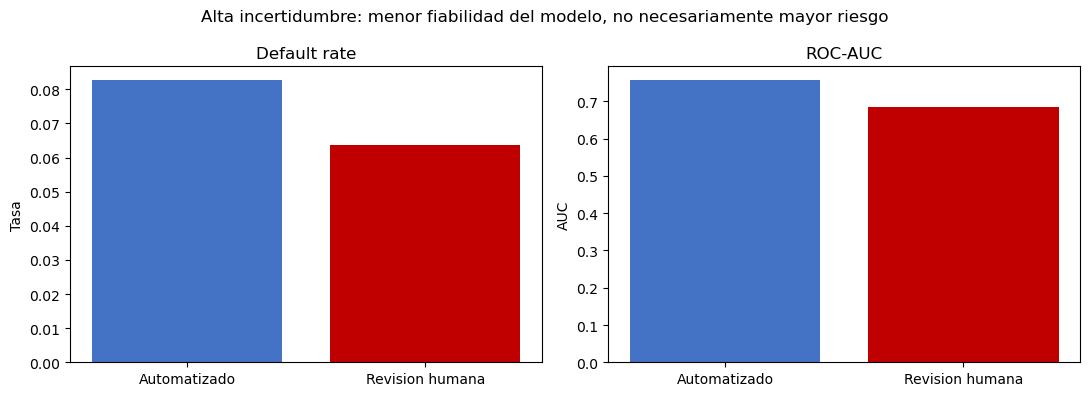

In [23]:
def mc_dropout_predict(model, inputs, n_samples=100):
    preds = []
    for _ in range(n_samples):
        pred = model(inputs, training=True).numpy().ravel()
        preds.append(pred)
    preds = np.asarray(preds)
    return preds.mean(axis=0), preds.var(axis=0), preds.std(axis=0)


assert_no_batchnorm(fair_final_model)

val_mean_mc_final, val_var_mc_final, val_std_mc_final = mc_dropout_predict(
    fair_final_model,
    [X_val_keras, X_val_fin_raw],
    n_samples=N_MC_SAMPLES,
)
uncertainty_threshold_final = float(np.percentile(val_var_mc_final, 90))

uncertainty_threshold_validation = pd.DataFrame([{
    "threshold_name": "p90_validation_variance_final",
    "value": uncertainty_threshold_final,
    "source_split": "validation",
    "n_mc_samples": N_MC_SAMPLES,
}])
uncertainty_threshold_validation.to_csv(TABLE_DIR / "uncertainty_threshold_validation.csv", index=False)

test_mean_mc_final, test_var_mc_final, test_std_mc_final = mc_dropout_predict(
    fair_final_model,
    [X_test_keras, X_test_fin_raw],
    n_samples=N_MC_SAMPLES,
)
test_pred_class_final = (test_mean_mc_final >= best_threshold_fair_final).astype(int)
high_uncertainty_final = test_var_mc_final >= uncertainty_threshold_final

test_predictions_with_uncertainty = pd.DataFrame({
    "SK_ID_CURR": ids_test.to_numpy(),
    "y_true": y_test_np.astype(int),
    "predicted_probability_mean": test_mean_mc_final,
    "predicted_class": test_pred_class_final,
    "predicted_label": np.where(test_pred_class_final == 1, "Mal pagador", "Buen pagador"),
    "prediction_variance": test_var_mc_final,
    "prediction_std": test_std_mc_final,
    "uncertainty_percentile": pd.Series(test_var_mc_final).rank(pct=True).to_numpy() * 100,
    "high_uncertainty": high_uncertainty_final,
    "CODE_GENDER_encoded": s_test_np.astype(int),
    "EXT_SOURCE_1": X_test_raw["EXT_SOURCE_1"].to_numpy(),
    "EXT_SOURCE_2": X_test_raw["EXT_SOURCE_2"].to_numpy(),
    "EXT_SOURCE_3": X_test_raw["EXT_SOURCE_3"].to_numpy(),
    "EXT_SOURCE_MISSING_COUNT": X_test_raw["EXT_SOURCE_MISSING_COUNT"].to_numpy(),
})
test_predictions_with_uncertainty.to_csv(TABLE_DIR / "test_predictions_with_uncertainty.csv", index=False)
test_predictions_with_uncertainty.to_csv(TABLE_DIR / "test_predictions_with_uncertainty_final.csv", index=False)

automated_final = ~high_uncertainty_final
review_final = high_uncertainty_final

roc_auc_automated = _safe_roc_auc(y_test_np[automated_final], test_mean_mc_final[automated_final])
roc_auc_human_review = _safe_roc_auc(y_test_np[review_final], test_mean_mc_final[review_final])
default_rate_automated = float(np.mean(y_test_np[automated_final]))
default_rate_human_review = float(np.mean(y_test_np[review_final]))

if pd.notna(roc_auc_human_review) and pd.notna(roc_auc_automated) and roc_auc_human_review < roc_auc_automated:
    reliability_interpretation = (
        "Alta incertidumbre indica menor fiabilidad: el modelo discrimina peor en los casos enviados a revision humana."
    )
else:
    reliability_interpretation = (
        "La alta incertidumbre no muestra peor discriminacion en este experimento; debe interpretarse con cautela."
    )
if default_rate_human_review <= default_rate_automated:
    reliability_interpretation += " Alta incertidumbre no implica mayor tasa de default."

selective_prediction_policy_results_final = pd.DataFrame([{
    "policy_name": "MC Dropout p90 validation final",
    "uncertainty_threshold_source": "validation",
    "uncertainty_threshold_value": uncertainty_threshold_final,
    "coverage_automated": float(automated_final.mean()),
    "coverage_human_review": float(review_final.mean()),
    "n_total_test": int(len(y_test_np)),
    "n_automated": int(automated_final.sum()),
    "n_human_review": int(review_final.sum()),
    "default_rate_automated": default_rate_automated,
    "default_rate_human_review": default_rate_human_review,
    "roc_auc_automated": roc_auc_automated,
    "roc_auc_human_review": roc_auc_human_review,
    "pr_auc_automated": _safe_pr_auc(y_test_np[automated_final], test_mean_mc_final[automated_final]),
    "pr_auc_human_review": _safe_pr_auc(y_test_np[review_final], test_mean_mc_final[review_final]),
    "mean_variance_automated": float(np.mean(test_var_mc_final[automated_final])),
    "mean_variance_human_review": float(np.mean(test_var_mc_final[review_final])),
    "interpretation": reliability_interpretation,
}])
selective_prediction_policy_results_final.to_csv(TABLE_DIR / "selective_prediction_policy_results_final.csv", index=False)
selective_prediction_policy_results_final.to_csv(TABLE_DIR / "selective_prediction_policy_results.csv", index=False)
selective_prediction_policy_results_final.to_csv(TABLE_DIR / "human_review_policy_summary.csv", index=False)
display(uncertainty_threshold_validation)
display(test_predictions_with_uncertainty.head(20))
display(selective_prediction_policy_results_final)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["Automatizado", "Revision humana"], [default_rate_automated, default_rate_human_review], color=["#4472C4", "#C00000"])
axes[0].set_title("Default rate")
axes[0].set_ylabel("Tasa")
axes[1].bar(["Automatizado", "Revision humana"], [roc_auc_automated, roc_auc_human_review], color=["#4472C4", "#C00000"])
axes[1].set_title("ROC-AUC")
axes[1].set_ylabel("AUC")
fig.suptitle("Alta incertidumbre: menor fiabilidad del modelo, no necesariamente mayor riesgo")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "selective_policy_reliability_not_risk.png", dpi=140, bbox_inches="tight")
plt.show()


## 22. Incertidumbre por clase predicha

La clase predicha mide riesgo estimado. La varianza de MC Dropout mide estabilidad. Por eso no se fuerza la lectura de que los malos pagadores predichos tengan siempre mas incertidumbre.


,predicted_label,n_obs,mean_variance,median_variance,p75_variance,p90_variance,real_default_rate,mean_predicted_probability,variance_relative_to_good,interpretation
0,Buen pagador,39786,0.0024,0.0022,0.0028,0.0034,0.0555,0.3755,1.0000,La incertidumbre media apenas separa clases pr...
1,Mal pagador,6341,0.0020,0.0019,0.0023,0.0027,0.2391,0.7432,0.8344,La incertidumbre media apenas separa clases pr...


**Interpretacion:** La incertidumbre media apenas separa clases predichas; su valor principal esta en detectar casos donde el modelo discrimina peor.

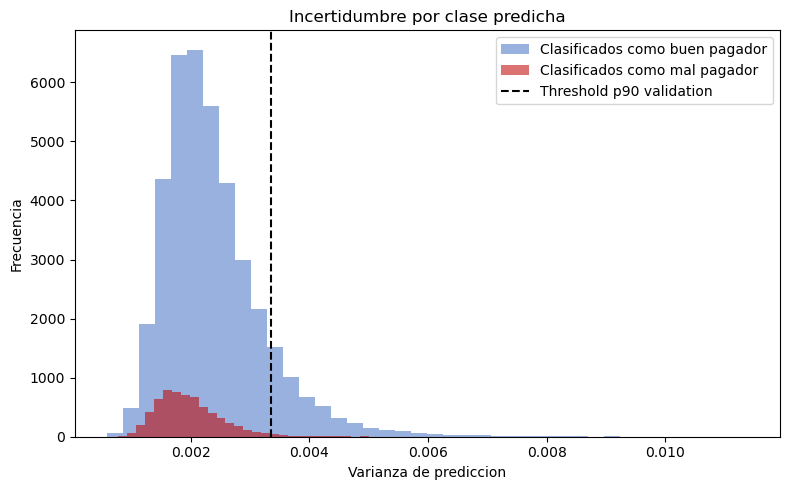

In [24]:
uncertainty_by_predicted_class_final = (
    test_predictions_with_uncertainty
    .groupby("predicted_label")
    .agg(
        n_obs=("prediction_variance", "size"),
        mean_variance=("prediction_variance", "mean"),
        median_variance=("prediction_variance", "median"),
        p75_variance=("prediction_variance", lambda x: np.percentile(x, 75)),
        p90_variance=("prediction_variance", lambda x: np.percentile(x, 90)),
        real_default_rate=("y_true", "mean"),
        mean_predicted_probability=("predicted_probability_mean", "mean"),
    )
    .reset_index()
)

good_mean = uncertainty_by_predicted_class_final.loc[
    uncertainty_by_predicted_class_final["predicted_label"] == "Buen pagador",
    "mean_variance",
]
bad_mean = uncertainty_by_predicted_class_final.loc[
    uncertainty_by_predicted_class_final["predicted_label"] == "Mal pagador",
    "mean_variance",
]
if len(good_mean) and len(bad_mean) and float(good_mean.iloc[0]) > 0:
    relative_diff = (float(bad_mean.iloc[0]) - float(good_mean.iloc[0])) / float(good_mean.iloc[0])
else:
    relative_diff = np.nan

if pd.notna(relative_diff) and relative_diff > 0.10:
    uncertainty_interpretation = "La incertidumbre es claramente mayor en los clasificados como mal pagador."
elif pd.notna(relative_diff) and relative_diff > 0.02:
    uncertainty_interpretation = "La incertidumbre es ligeramente mayor en los clasificados como mal pagador, pero la diferencia es moderada."
else:
    uncertainty_interpretation = "La incertidumbre media apenas separa clases predichas; su valor principal esta en detectar casos donde el modelo discrimina peor."

base_variance = float(good_mean.iloc[0]) if len(good_mean) else np.nan
uncertainty_by_predicted_class_final["variance_relative_to_good"] = (
    uncertainty_by_predicted_class_final["mean_variance"] / base_variance
)
uncertainty_by_predicted_class_final["interpretation"] = uncertainty_interpretation
uncertainty_by_predicted_class_final.to_csv(TABLE_DIR / "uncertainty_by_predicted_class_final.csv", index=False)
uncertainty_by_predicted_class_final.to_csv(TABLE_DIR / "uncertainty_by_predicted_class.csv", index=False)
display(uncertainty_by_predicted_class_final)
display(Markdown(f"**Interpretacion:** {uncertainty_interpretation}"))

plt.figure(figsize=(8, 5))
for label, color in [("Buen pagador", "#4472C4"), ("Mal pagador", "#C00000")]:
    values = test_predictions_with_uncertainty.loc[
        test_predictions_with_uncertainty["predicted_label"] == label,
        "prediction_variance",
    ]
    plt.hist(values, bins=40, alpha=0.55, label=f"Clasificados como {label.lower()}", color=color)
plt.axvline(uncertainty_threshold_final, color="black", linestyle="--", label="Threshold p90 validation")
plt.xlabel("Varianza de prediccion")
plt.ylabel("Frecuencia")
plt.title("Incertidumbre por clase predicha")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "uncertainty_distribution_predicted_class_final.png", dpi=140, bbox_inches="tight")
plt.savefig(FIGURE_DIR / "uncertainty_distribution_predicted_good_vs_bad.png", dpi=140, bbox_inches="tight")
plt.show()


## 23. EXT_SOURCE e incertidumbre

Se agrupa la calidad de informacion externa segun cuantas variables `EXT_SOURCE` faltan. Despues se mira la incertidumbre tambien por deciles de riesgo para no confundir missingness con riesgo predicho.


,ext_source_quality_group,n_obs,mean_prediction_variance,median_prediction_variance,p90_prediction_variance,real_default_rate,mean_predicted_probability,roc_auc_group
0,Alta calidad,16429,0.0024,0.0022,0.0035,0.0725,0.3995,0.7638
2,Calidad media,24111,0.0022,0.0021,0.0032,0.0826,0.4316,0.7499
1,Baja calidad,5587,0.0025,0.0023,0.0037,0.0968,0.4798,0.7164


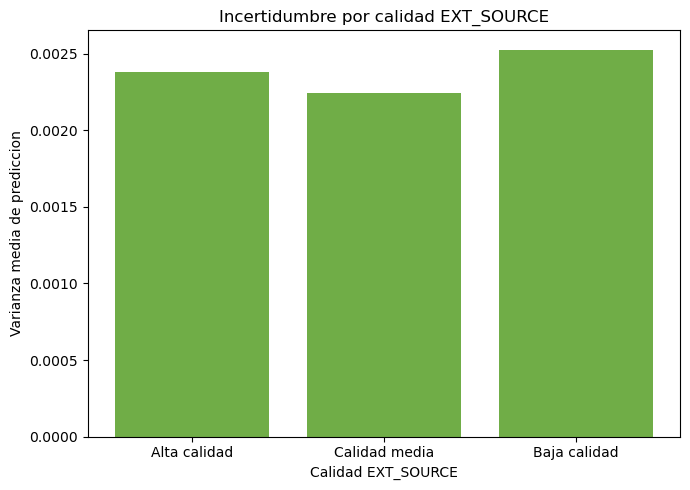

,risk_decile,ext_source_quality_group,n_obs,mean_predicted_probability,real_default_rate,mean_prediction_variance,median_prediction_variance
0,0,Alta calidad,2286,0.1436,0.0127,0.0019,0.0018
1,0,Baja calidad,208,0.1504,0.0385,0.0022,0.0021
2,0,Calidad media,2119,0.1468,0.0109,0.0020,0.0019
3,1,Alta calidad,1951,0.2190,0.0179,0.0024,0.0023
4,1,Baja calidad,311,0.2212,0.0257,0.0027,0.0024
5,1,Calidad media,2351,0.2195,0.0234,0.0024,0.0022
6,2,Alta calidad,1831,0.2776,0.0268,0.0025,0.0023
7,2,Baja calidad,470,0.2773,0.0319,0.0027,0.0024
8,2,Calidad media,2311,0.2783,0.0342,0.0024,0.0023
9,3,Alta calidad,1721,0.3321,0.0413,0.0024,0.0022


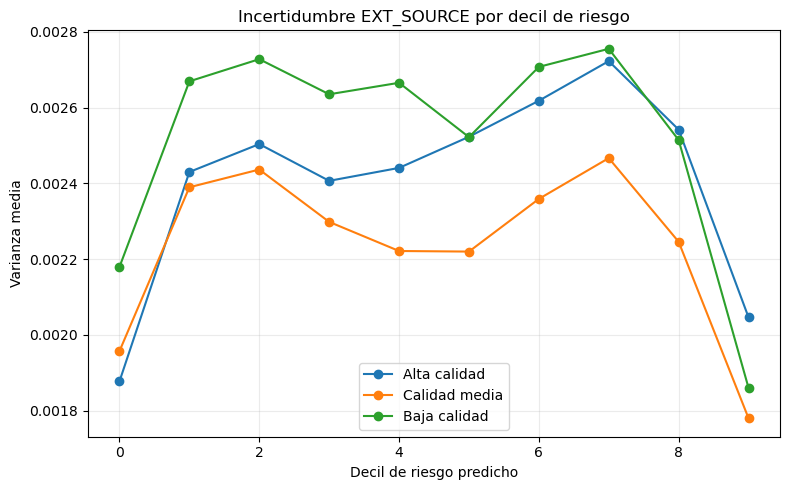

In [25]:
def ext_source_quality_group(missing_count):
    if missing_count == 0:
        return "Alta calidad"
    if missing_count == 1:
        return "Calidad media"
    return "Baja calidad"


test_predictions_with_uncertainty["EXT_SOURCE_AVAILABLE_COUNT"] = (
    3 - test_predictions_with_uncertainty["EXT_SOURCE_MISSING_COUNT"]
)
test_predictions_with_uncertainty["ext_source_quality_group"] = (
    test_predictions_with_uncertainty["EXT_SOURCE_MISSING_COUNT"].apply(ext_source_quality_group)
)

quality_rows = []
for group, part in test_predictions_with_uncertainty.groupby("ext_source_quality_group"):
    quality_rows.append({
        "ext_source_quality_group": group,
        "n_obs": len(part),
        "mean_prediction_variance": part["prediction_variance"].mean(),
        "median_prediction_variance": part["prediction_variance"].median(),
        "p90_prediction_variance": np.percentile(part["prediction_variance"], 90),
        "real_default_rate": part["y_true"].mean(),
        "mean_predicted_probability": part["predicted_probability_mean"].mean(),
        "roc_auc_group": _safe_roc_auc(part["y_true"], part["predicted_probability_mean"]),
    })

uncertainty_by_ext_source_quality_final = pd.DataFrame(quality_rows)
quality_order = {"Alta calidad": 0, "Calidad media": 1, "Baja calidad": 2}
uncertainty_by_ext_source_quality_final["order"] = (
    uncertainty_by_ext_source_quality_final["ext_source_quality_group"].map(quality_order)
)
uncertainty_by_ext_source_quality_final = (
    uncertainty_by_ext_source_quality_final.sort_values("order").drop(columns="order")
)
uncertainty_by_ext_source_quality_final.to_csv(TABLE_DIR / "uncertainty_by_ext_source_quality_final.csv", index=False)
uncertainty_by_ext_source_quality_final.to_csv(TABLE_DIR / "uncertainty_by_ext_source_quality.csv", index=False)
display(uncertainty_by_ext_source_quality_final)

plt.figure(figsize=(7, 5))
plt.bar(
    uncertainty_by_ext_source_quality_final["ext_source_quality_group"],
    uncertainty_by_ext_source_quality_final["mean_prediction_variance"],
    color="#70AD47",
)
plt.xlabel("Calidad EXT_SOURCE")
plt.ylabel("Varianza media de prediccion")
plt.title("Incertidumbre por calidad EXT_SOURCE")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "uncertainty_by_ext_source_quality.png", dpi=140, bbox_inches="tight")
plt.show()

test_predictions_with_uncertainty["risk_decile"] = pd.qcut(
    test_predictions_with_uncertainty["predicted_probability_mean"],
    10,
    labels=False,
    duplicates="drop",
)
uncertainty_ext_source_by_risk_decile_final = (
    test_predictions_with_uncertainty
    .groupby(["risk_decile", "ext_source_quality_group"])
    .agg(
        n_obs=("prediction_variance", "size"),
        mean_predicted_probability=("predicted_probability_mean", "mean"),
        real_default_rate=("y_true", "mean"),
        mean_prediction_variance=("prediction_variance", "mean"),
        median_prediction_variance=("prediction_variance", "median"),
    )
    .reset_index()
)
uncertainty_ext_source_by_risk_decile_final.to_csv(TABLE_DIR / "uncertainty_ext_source_by_risk_decile_final.csv", index=False)
uncertainty_ext_source_by_risk_decile_final.to_csv(TABLE_DIR / "uncertainty_ext_source_by_risk_decile.csv", index=False)
display(uncertainty_ext_source_by_risk_decile_final.head(20))

plt.figure(figsize=(8, 5))
for group in ["Alta calidad", "Calidad media", "Baja calidad"]:
    part = uncertainty_ext_source_by_risk_decile_final[
        uncertainty_ext_source_by_risk_decile_final["ext_source_quality_group"] == group
    ]
    if not part.empty:
        plt.plot(part["risk_decile"], part["mean_prediction_variance"], marker="o", label=group)
plt.xlabel("Decil de riesgo predicho")
plt.ylabel("Varianza media")
plt.title("Incertidumbre EXT_SOURCE por decil de riesgo")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "uncertainty_ext_source_by_risk_decile.png", dpi=140, bbox_inches="tight")
plt.show()


## 24. Tabla general de modelos

La tabla final separa roles:

- benchmark predictivo;
- modelo neuronal base;
- modelo neuronal FAIR;
- AutoML predictivo;
- politica selectiva, cuando aplique.

Si HistGradientBoosting lidera AUC, eso no invalida el objetivo de la practica: el modelo central es la red FAIR final porque integra capa custom, fairness e incertidumbre.


In [26]:
def assign_role(row):
    name = str(row.get("model", ""))
    scope = row.get("evaluation_scope", "full_test")
    if scope == "selective_coverage":
        return "politica selectiva"
    if "HistGradientBoosting" in name:
        return "benchmark predictivo"
    if "AutoML" in name or "Keras Tuner" in name:
        return "automl predictivo"
    if "FAIR" in name:
        return "modelo neuronal fair"
    if "Base" in name or "Neural" in name or "NN" in name:
        return "modelo neuronal base"
    return "benchmark predictivo"


existing_results = results_df.copy() if "results_df" in globals() else pd.DataFrame(results_full_test)
final_rows_for_general = pd.DataFrame([base_final_test_metrics, fair_final_test_metrics])
model_comparison_results = pd.concat([existing_results, final_rows_for_general], ignore_index=True, sort=False)
model_comparison_results["evaluation_scope"] = model_comparison_results.get("evaluation_scope", "full_test").fillna("full_test")
model_comparison_results["role"] = model_comparison_results.apply(assign_role, axis=1)
model_comparison_results.to_csv(TABLE_DIR / "model_comparison_results.csv", index=False)
display(model_comparison_results.sort_values("roc_auc", ascending=False))


,model,threshold_strategy,threshold,accuracy,balanced_accuracy,roc_auc,pr_auc,brier_score,precision,recall,f1,tn,fp,fn,tp,mean_prediction,default_rate_real,corr_pred_gender,demographic_parity_gap_score,demographic_parity_gap_label,equal_opportunity_gap,fpr_gap,evaluation_scope,validation_best_f1,lambda_corr,role
2,HistGradientBoosting,best_f1_validation,0.1600,0.8588,0.6513,0.7605,0.2552,0.0674,0.2594,0.4039,0.3159,38110,4293,2220,1504,0.0809,0.0807,0.1172,0.0194,0.0645,0.1009,0.0514,full_test,0.3083,NaN,benchmark predictivo
4,Base NN Final sin FAIR,best_f1_validation,0.6500,0.8437,0.6526,0.7537,0.2407,0.1958,0.2379,0.4248,0.3050,37335,5068,2142,1582,0.4141,0.0807,0.1438,0.0590,0.0817,0.1175,0.0686,full_test,NaN,0.0000,modelo neuronal fair
3,AutoML Keras Tuner,best_f1_validation,0.6500,0.8387,0.6537,0.7515,0.2372,0.2027,0.2323,0.4331,0.3024,37072,5331,2111,1613,0.4242,0.0807,0.1392,0.0566,0.0827,0.0998,0.0713,full_test,NaN,NaN,automl predictivo
5,FAIR NN Final,best_f1_validation,0.6600,0.8433,0.6481,0.7515,0.2397,0.2014,0.2345,0.4154,0.2997,37352,5051,2177,1547,0.4225,0.0807,0.0428,0.0174,0.0430,0.0435,0.0335,full_test,NaN,0.8000,modelo neuronal fair
1,Logistic Regression,best_f1_validation,0.6600,0.8396,0.6494,0.7470,0.2346,0.2051,0.2306,0.4227,0.2984,37152,5251,2150,1574,0.4249,0.0807,0.1338,0.0563,0.0751,0.0904,0.0641,full_test,0.2919,NaN,benchmark predictivo
0,Dummy prior,best_f1_validation,0.0100,0.0807,0.5000,0.5000,0.0807,0.0742,0.0807,1.0000,0.1494,0,42403,0,3724,0.0807,0.0807,NaN,0.0000,0.0000,0.0000,0.0000,full_test,0.1494,NaN,benchmark predictivo
